# Топологические и статистические метрики схожести распределений

Курсовой проект. Переработанная и дополненная версия `topology_metrics_RnD.ipynb`.

**Цель** — посмотреть, как разные метрики схожести двух облаков точек (данные $P$ vs модель $Q$) реагируют на контролируемую деформацию распределений, и проверить гипотезу научного руководителя: *precision/recall-метрики сильнее коррелируют между собой, чем с симметричными метриками-расходимостями, и наоборот*.

## Метрики

| Метрика | Тип | Что измеряет |
|---|---|---|
| **MTD** (Manifold Topology Divergence) | асимметричная, топологическая | сумму длин $H_1$-баров кросс-баркода пары облаков |
| **RTD** (Representation Topology Divergence) | симметричная, топологическая | расхождение топологий внутренних структур двух облаков |
| **Improved precision / recall** | асимметричная | долю точек одного облака внутри kNN-многообразия другого |
| **MMD** (Maximum Mean Discrepancy) | симметричная | расстояние между распределениями в RKHS (RBF-ядро) |
| **Fréchet distance** | симметричная | $W_2$-расстояние между гауссианами, подогнанными к облакам (формула FID) |
| **JS divergence** | симметричная | дивергенцию Дженсена–Шеннона между плотностями (kNN-оценка) |

## Структура ноутбука

1. **Генерация данных** — сэмплеры для управляемых 2D-экспериментов
2. **Метрики** — класс-обертка `TopologyMetrics`, детали реализации библиотек, sanity-проверки
3. **Синтетические эксперименты** — кольцо/диск/смесь с деформацией (нумерация из переписки)
4. **Корреляционный анализ** — проверка гипотезы
5. **Реальные данные** — эмбеддинги CLIP: MNIST, Fashion-MNIST, CIFAR-10-C
6. **Итоги и литература**

> **Требования к окружению:** GPU-runtime Google Colab — ripser++ (используется в MTD и RTD) собирается только с CUDA. Improved precision/recall и статистические метрики (MMD, Fréchet, JS) работают и на CPU: TF запускается с `allow_soft_placement`.


## Задачи из переписки и их статус

| # | Задача (из переписки) | Было в RnD-ноутбуке | Где сейчас |
|---|---|---|---|
| 1 | 100 точек: гауссиана + равномерный квадрат; MTD в обе стороны, precision, recall | не те распределения (две одинаковые усеченные гауссианы) | § 2.3 |
| 2 | FID | не сделано | § 2.1: `frechet_distance` — формула FID на сырых фичах; на эмбеддингах — § 5 |
| 3 | Симметричные метрики: JS-дивергенция для наборов векторов | не сделано | § 2.1: `js_divergence` (kNN-оценка энтропий) |
| 4 | MMD | сделано, фиксированное `gamma=1.0` | § 2.1: несмещенная оценка + медианная эвристика |
| 5 | Класс-обертка: два облака на вход, метрики через методы | сделано | § 2.1: `TopologyMetrics` |
| 6 | Форк improved-precision-recall: setup.py, запуск в Colab | сделано | § 0 (установка) |
| 7 | Разобраться с деталями реализации rtd / mtd / precision_recall | вопросы в комментариях ячеек | § 2.2 (ответы на все вопросы) |
| 8 | MTD: по каким гомологиям считается расстояние (H0 / H1) | не сделано | § 2.1: `mtd_homology`; § 2.2 |
| 9 | Разные сиды для двух облаков вместо копий | частично (`deepcopy`) | § 3 (везде разные сиды) |
| 10 | Эксперимент 1: два кольца, одно двигаем | сделано | § 3.1 |
| 11 | Эксперименты 2а/2б: диск (данные) vs кольцо (модель) и наоборот | только 2а | § 3.2–3.3 |
| 12 | Эксперименты 3а/3б: гауссиана vs раздвигающаяся смесь и наоборот | только 3а | § 3.4–3.5 |
| 13 | Смесь: параметр числа компонент (4, 8, ...) | сделано | § 3.6 |
| 14 | Корреляция precision/recall-метрик между собой и с симметричными | не сделано | § 4 |
| 15 | Реальные данные через предобученную модель (эмбеддинги) | обсуждалось | § 5 (CLIP) |

**Исправленные ошибки старого ноутбука:**

- опечатка `figsize=(10,5b))` → `SyntaxError` в разделе Sphere metrics;
- лишний сдвиг `moved_points[:, 0] += step` в эксперименте со смесью (сдвигал облако, хотя эксперимент про раздвигание компонент);
- избыточный двойной вызов `knn_precision_recall_features` со swapped аргументами (второй вызов возвращает те же precision/recall с точностью до перестановки);
- MMD с фиксированным `gamma=1.0` — метрика зависела от масштаба данных (теперь медианная эвристика);
- загадка «облака совпадают полностью, а MTD не ноль» — облака совпадали только визуально: это были две выборки одного закона с разными сидами; ненулевой MTD и precision/recall < 1 — корректный шум сэмплирования, а не баг (разбор в § 2.3);
- шестикратное копирование кода экспериментов → общий пайплайн `run_experiment` (§ 3).


## 0. Установка

Установка занимает ~5 минут (ripser++ компилируется с CUDA). Повторный запуск ячеек безопасен: `git clone` пропустится, `pip install` переустановит то же самое.

Ключевые зависимости:

- **ripser++** — GPU-вычисление персистентных гомологий (нужен MTD и RTD);
- **MTopDiv** — Manifold Topology Divergence;
- **RTD** — Representation Topology Divergence;
- **improved-precision-and-recall-metric** — форк [AlimAlb/improved-precision-and-recall-metric](https://github.com/AlimAlb/improved-precision-and-recall-metric): добавлен `setup.py` и включен режим совместимости с TF1, чтобы ставился в Colab без костылей (задача № 6 из таблицы выше).


In [ ]:
# ripser++: требуется GPU-runtime (сборка с CUDA)
!git clone --recursive https://github.com/simonzhang00/ripser-plusplus.git 2> /dev/null || echo 'ripser-plusplus: уже склонирован'
!pip install -q ./ripser-plusplus

# MTD (Manifold Topology Divergence)
!git clone https://github.com/IlyaTrofimov/MTopDiv.git 2> /dev/null || echo 'MTopDiv: уже склонирован'
!pip install -q ./MTopDiv

# RTD (Representation Topology Divergence)
!pip install -q git+https://github.com/IlyaTrofimov/RTD.git

# improved precision/recall: форк с setup.py и правками TF1-режима
!git clone https://github.com/AlimAlb/improved-precision-and-recall-metric.git 2> /dev/null || echo 'improved-precision-and-recall: уже склонирован'
!pip install -q ./improved-precision-and-recall-metric


ripser-plusplus: уже склонирован


  Preparing metadata (setup.py) ... done


MTopDiv: уже склонирован


  Preparing metadata (setup.py) ... done


  Preparing metadata (setup.py) ... done


improved-precision-and-recall: уже склонирован


  Preparing metadata (setup.py) ... done


### Импорты

`precision_recall` написан под TF1, поэтому перед импортом включаем режим совместимости TensorFlow (`disable_eager_execution` + `disable_v2_behavior`). Импорт `mtd` и `rtd` сразу проверяет, что ripser++ собрался: если сборка не удалась — упадет здесь с понятной ошибкой.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
tf.compat.v1.disable_eager_execution()
tf.compat.v1.disable_v2_behavior()

import mtd
import rtd
from precision_recall import knn_precision_recall_features

print(f'numpy {np.__version__} | tensorflow {tf.__version__} | pandas {pd.__version__}')
print('mtd, rtd, precision_recall: импортированы успешно')


numpy 2.1.3 | tensorflow 2.20.0 | pandas 2.2.3
mtd, rtd, precision_recall: импортированы успешно


## 1. Генерация данных

Все сэмплеры детерминированы через `seed` (`np.random.default_rng`) и возвращают массив `(n, dim)`.

### Равномерный диск (шар)

Чтобы точки заполняли диск **равномерно по площади**, нельзя брать радиус как $U[0, R]$ — точки сгустятся у центра. Нужно, чтобы $P(r' < r)$ равнялась доле объема:

$$P(r' < r) = \frac{V(r)}{V(R)} = \left(\frac{r}{R}\right)^{dim}$$

Пусть $U \sim U[0,1]$, тогда $U = (r/R)^{dim} \Rightarrow r = R \cdot U^{1/dim}$.

### Толстое кольцо

Направление — нормализованный гауссовский вектор (равномерен на сфере), радиус — $N(R,\ \text{thickness}/4)$: «правило $4\sigma$», т.е. эффективная толщина кольца $\approx$ `thickness` ($\pm 2\sigma$). При `thickness=0` — окружность.

### Смесь гауссиан с сохранением моментов

Смесь из `n_components` равновесых гауссиан устроена так, что при любом `radius` её глобальные mean/cov совпадают с $N(\mu, \Sigma)$:

1. работаем в whitened-пространстве, где эталон $\sim N(0, I)$, а затем возвращаемся аффинным преобразованием $X = \mu + LZ$, где $\Sigma = LL^\top$;
2. центры компонент лежат на окружности радиуса `radius` равномерно по углу, поэтому $E[c_i c_i^\top] = \frac{radius^2}{2} I$;
3. дисперсия каждой компоненты $\sigma_c^2 = 1 - radius^2/2$ — вместе с $\frac{radius^2}{2}$ дает ковариацию $I$.

Растущий `radius` раздвигает компоненты, **не меняя глобальных моментов** — это «эксперимент с раздвигающейся смесью» (задачи № 12–13). Ограничения: $radius^2 < 2$ (иначе $\sigma_c^2 \le 0$); `n_components` $= 1$ или $\ge 3$ — при двух компонентах на окружности $E[c\,c^\top] = \mathrm{diag}(r^2, 0)$ и изотропность ломается.


In [ ]:
def sample_gaussian(n, dim=2, mean=None, cov=None, seed=None):
    """Точки из N(mean, cov)."""
    rng = np.random.default_rng(seed)
    mean = np.zeros(dim) if mean is None else np.asarray(mean, dtype=float)
    cov = np.eye(dim) if cov is None else np.asarray(cov, dtype=float)
    return rng.multivariate_normal(mean, cov, size=n)


def sample_uniform_cube(n, dim=2, side=1.0, seed=None):
    """Равномерно в кубе [-side/2, side/2]^dim (dim=2, side=1 — единичный квадрат)."""
    rng = np.random.default_rng(seed)
    return (rng.random((n, dim)) - 0.5) * side


def sample_ball(n, dim=2, radius=1.0, center=None, seed=None):
    """Равномерно по объему шара радиуса radius (в 2D — диск).

    Радиус сэмплируется как r = R * U^(1/dim): тогда P(r' < r) = (r/R)^dim,
    т.е. точки заполняют шар равномерно, а не сгустаются у центра.
    """
    rng = np.random.default_rng(seed)
    directions = rng.normal(size=(n, dim))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    radii = radius * rng.random(n) ** (1.0 / dim)
    points = directions * radii[:, None]
    if center is not None:
        points = points + np.asarray(center, dtype=float)
    return points


def sample_ring(n, dim=2, radius=1.0, thickness=0.0, center=None, seed=None):
    """Толстое кольцо: направление равномерно на сфере, радиус ~ N(radius, thickness/4).

    thickness задает эффективную толщину ±2σ (правило 4σ); при thickness=0 — окружность.
    """
    rng = np.random.default_rng(seed)
    directions = rng.normal(size=(n, dim))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    radii = np.maximum(rng.normal(radius, thickness / 4.0, size=n), 0.0)
    points = directions * radii[:, None]
    if center is not None:
        points = points + np.asarray(center, dtype=float)
    return points


def sample_gaussian_mixture(n, radius=0.0, n_components=4, mean=(0.0, 0.0), cov=None, seed=None):
    """Смесь равновесых 2D-гауссиан с сохранением глобальных моментов.

    Центры компонент лежат в whitened-пространстве на окружности радиуса `radius`
    (равномерно по углу), дисперсия каждой компоненты sigma_c^2 = 1 - radius^2 / 2
    подобрана так, что итоговое распределение имеет те же mean и cov, что и
    N(mean, cov). При radius=0 вырождается в обычную гауссиану.

    Ограничения: radius^2 < 2; n_components = 1 или >= 3 — при двух компонентах
    изотропность ковариации нарушается.
    """
    rng = np.random.default_rng(seed)
    mean = np.asarray(mean, dtype=float)
    cov = np.eye(2) if cov is None else np.asarray(cov, dtype=float)
    if mean.shape != (2,) or cov.shape != (2, 2):
        raise ValueError('смесь определена только в 2D (mean (2,), cov (2, 2))')
    if n_components < 1:
        raise ValueError('n_components должен быть >= 1')
    if n_components == 1:
        if radius != 0.0:
            raise ValueError('n_components=1 поддерживается только при radius=0')
        return rng.multivariate_normal(mean, cov, size=n)
    if n_components == 2:
        raise ValueError('n_components=2 не поддерживается: нарушается изотропность ковариации')
    if radius ** 2 >= 2.0:
        raise ValueError('radius^2 должен быть < 2')

    angles = np.linspace(0.0, 2.0 * np.pi, n_components, endpoint=False)
    centers = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    std_component = np.sqrt(1.0 - 0.5 * radius ** 2)

    comp_idx = rng.integers(0, n_components, size=n)
    z = centers[comp_idx] + rng.normal(size=(n, 2)) * std_component

    transform = np.linalg.cholesky(cov)
    return mean + z @ transform.T


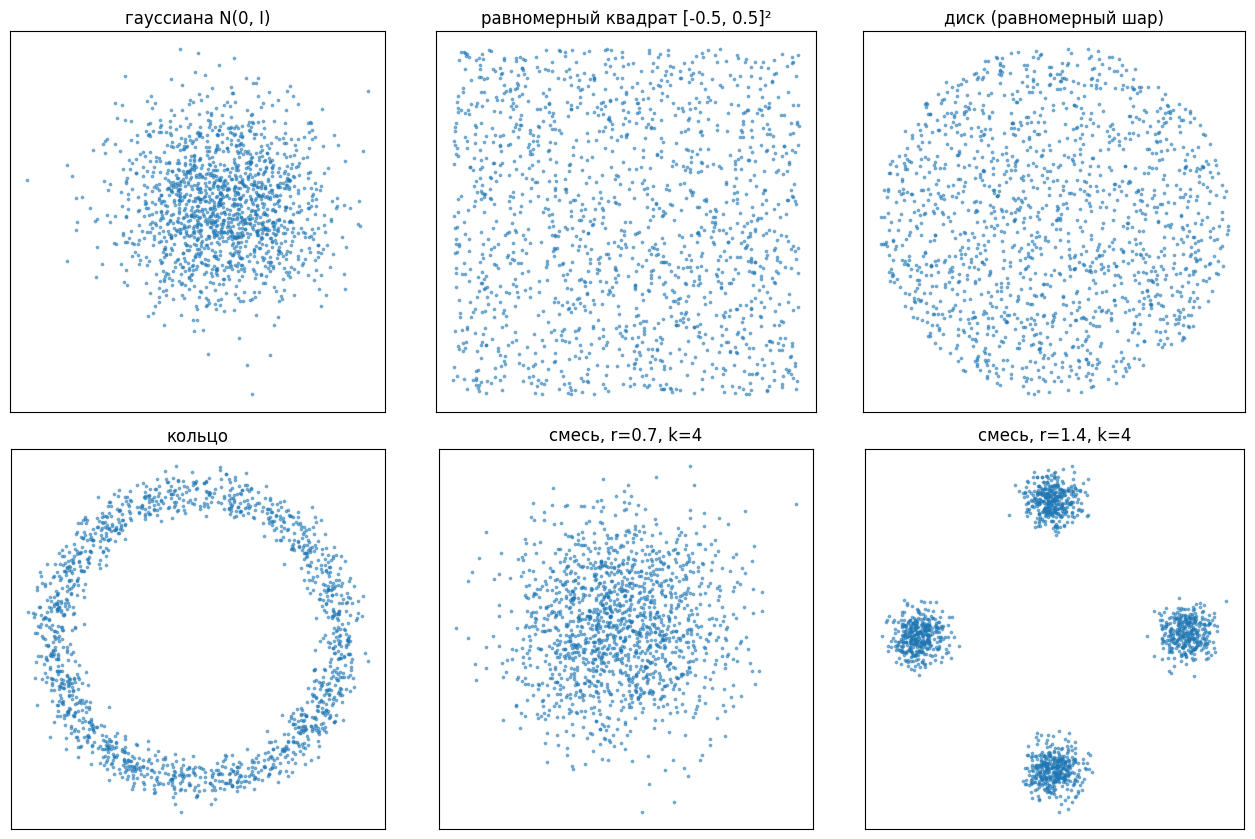

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))

panels = [
    (sample_gaussian(1500, seed=0), 'гауссиана N(0, I)'),
    (sample_uniform_cube(1500, seed=0), 'равномерный квадрат [-0.5, 0.5]²'),
    (sample_ball(1500, radius=1.0, seed=0), 'диск (равномерный шар)'),
    (sample_ring(1500, radius=1.0, thickness=0.3, seed=0), 'кольцо'),
    (sample_gaussian_mixture(1500, radius=0.7, n_components=4, seed=0), 'смесь, r=0.7, k=4'),
    (sample_gaussian_mixture(1500, radius=1.4, n_components=4, seed=0), 'смесь, r=1.4, k=4'),
]
for ax, (points, title) in zip(axes.flat, panels):
    ax.scatter(points[:, 0], points[:, 1], s=3, alpha=0.5)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


## 2. Метрики

### 2.1. Класс-обертка `TopologyMetrics`

Задача № 5: передаем два облака точек — получаем метрики через методы, либо все сразу плоским словарем через `compute_all` (одна запись = одна строка `pandas.DataFrame`).

Соглашения:

- **P — «данные» (reference), Q — «модель»**: для асимметричных метрик направление важно; `compute_all` возвращает оба направления MTD (`mtd_PQ`, `mtd_QP`);
- стохастические внутренности библиотек (подсэмплирование в MTD/RTD) фиксируются контекст-менеджером `np_random_seed` — результат не зависит от порядка вызовов;
- MMD / Fréchet / JS реализованы здесь же: несмещенные/стабильные версии с медианной эвристикой и регуляризацией ковариаций (детали в § 2.2).


In [ ]:
from contextlib import contextmanager

from scipy.linalg import sqrtm
from scipy.special import digamma, gammaln
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist, pdist


@contextmanager
def np_random_seed(seed):
    """Детерминирует глобальный numpy RNG внутри блока.

    mtd и rtd используют глобальный np.random для подсэмплирования — фиксируем
    состояние на время вызова, чтобы метрики не зависели от порядка выполнения.
    """
    state = np.random.get_state()
    np.random.seed(seed)
    try:
        yield
    finally:
        np.random.set_state(state)


class TopologyMetrics:
    """Единый интерфейс к метрикам схожести двух облаков точек.

    P — «данные» (reference), Q — «модель».

    Асимметричные: mtd (направления P->Q и Q->P), improved precision/recall.
    Симметричные: rtd, mmd, frechet, js.

    Параметры:
        seed: сид для стохастических внутренних подсэмплирований (mtd, rtd);
        device: 'cpu' | 'cuda:N' — где считать попарные расстояния.
    """

    def __init__(self, seed=42, device='cpu'):
        self.seed = seed
        self.device = device

    # ---------- топологические ----------

    def mtd(self, P, Q, batch_size1=None, batch_size2=None, n=1):
        """Manifold Topology Divergence: сумма длин H1-баров кросс-баркода.

        Асимметрична: считайте mtd(P, Q) и mtd(Q, P).
        batch_size1 / batch_size2 — сколько точек брать из P и Q (по умолчанию все);
        n — число повторов со случайным подсэмплированием (нужно только если
        батчи меньше облаков).
        """
        bs1 = len(P) if batch_size1 is None else min(batch_size1, len(P))
        bs2 = len(Q) if batch_size2 is None else min(batch_size2, len(Q))
        with np_random_seed(self.seed):
            value = mtd.mtopdiv(
                P, Q, batch_size1=bs1, batch_size2=bs2, n=n, pdist_device=self.device,
            )
        return float(value)

    def mtd_homology(self, P, Q):
        """Суммы длин баров кросс-баркода по гомологиям: H0 — связность, H1 — циклы.

        mtd(P, Q) эквивалентен mtd_homology(P, Q)['H1'] при полных батчах.
        """
        with np_random_seed(self.seed):
            barcodes = mtd.calc_cross_barcodes(
                P, Q,
                batch_size1=len(P), batch_size2=len(Q),
                pdist_device=self.device, dim=1, is_plot=False,
            )
        scores = {}
        for level, bars in enumerate(barcodes):
            bars = np.asarray(bars, dtype=float).reshape(-1, 2)
            scores[f'H{level}'] = float(np.sum(bars[:, 1] - bars[:, 0]))
        return scores

    def rtd(self, P, Q, trials=10, batch=500):
        """Representation Topology Divergence. Симметрична, требует |P| == |Q|."""
        if len(P) != len(Q):
            raise ValueError('rtd определен для облаков одинакового размера')
        with np_random_seed(self.seed):
            value = rtd.rtd(
                P, Q, pdist_device=self.device, trials=trials, batch=min(batch, len(P)),
            )
        return float(value)

    # ---------- precision / recall ----------

    def improved_precision_recall(self, P, Q, nhood_sizes=(1, 3, 10)):
        """Improved precision and recall (Kynkäänniemi et al., 2019).

        precision@k — доля точек Q внутри kNN-многообразия P;
        recall@k — доля точек P внутри kNN-многообразия Q.
        Возвращает плоский словарь {'precision@k': ..., 'recall@k': ...}.
        """
        config = tf.compat.v1.ConfigProto(allow_soft_placement=True)
        with tf.compat.v1.Session(config=config):
            state = knn_precision_recall_features(
                P, Q,
                nhood_sizes=list(nhood_sizes),
                row_batch_size=10000,
                col_batch_size=50000,
                num_gpus=1,
            )
        tf.compat.v1.reset_default_graph()
        return {
            **{f'precision@{k}': float(v) for k, v in zip(nhood_sizes, state['precision'])},
            **{f'recall@{k}': float(v) for k, v in zip(nhood_sizes, state['recall'])},
        }

    # ---------- симметричные статистические ----------

    def mmd(self, P, Q, gamma='median'):
        """Maximum Mean Discrepancy с RBF-ядром; несмещенная оценка MMD^2, возвращается корень.

        gamma='median' — медианная эвристика: gamma = 1 / median^2, где median —
        медиана попарных расстояний объединенной выборки (т.е. sigma = median / sqrt(2)).
        """
        pooled = np.vstack([P, Q])
        if gamma == 'median':
            median = float(np.median(pdist(pooled)))
            gamma = 1.0 / max(median ** 2, 1e-12)

        def rbf_kernel(A, B):
            return np.exp(-gamma * cdist(A, B, metric='sqeuclidean'))

        Kxx, Kyy, Kxy = rbf_kernel(P, P), rbf_kernel(Q, Q), rbf_kernel(P, Q)
        n, m = len(P), len(Q)
        mmd2 = (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1)) \
             + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1)) \
             - 2.0 * Kxy.mean()
        return float(np.sqrt(max(mmd2, 0.0)))

    def frechet_distance(self, P, Q):
        """Fréchet distance между гауссианами, подогнанными к облакам (формула FID).

        d^2 = ||mu1 - mu2||^2 + tr(S1 + S2 - 2 (S1 S2)^(1/2)).
        Классический FID — та же формула на фичах InceptionV3. Ковариации
        регуляризуются eps*I — важно при d > n (эмбеддинги в § 5).
        """
        mu1, mu2 = P.mean(axis=0), Q.mean(axis=0)
        S1, S2 = np.cov(P, rowvar=False), np.cov(Q, rowvar=False)
        d = P.shape[1]
        S1 = S1 + (1e-8 * np.trace(S1) / d + 1e-12) * np.eye(d)
        S2 = S2 + (1e-8 * np.trace(S2) / d + 1e-12) * np.eye(d)
        cov_mean = sqrtm(S1 @ S2)
        if np.iscomplexobj(cov_mean):
            cov_mean = cov_mean.real
        d2 = np.sum((mu1 - mu2) ** 2) + np.trace(S1) + np.trace(S2) - 2.0 * np.trace(cov_mean)
        return float(np.sqrt(max(d2, 0.0)))

    def js_divergence(self, P, Q, k=5):
        """Дивергенция Дженсена–Шеннона (в битах, 0 <= JS <= 1) для наборов точек.

        JS(P, Q) = H(M) - (H(P) + H(Q)) / 2, где M — смесь 0.5P + 0.5Q; объединенная
        выборка — честная выборка из M. Энтропии — kNN-оценка Козаченко–Леоненко.
        """

        def knn_entropy(X):
            n, d = X.shape
            dist, _ = cKDTree(X).query(X, k=k + 1)
            rho = np.maximum(dist[:, -1], 1e-12)
            log_ball_volume = 0.5 * d * np.log(np.pi) - gammaln(0.5 * d + 1.0)
            return digamma(n) - digamma(k) + log_ball_volume + (d / n) * np.sum(np.log(rho))

        pooled = np.vstack([P, Q])
        js = knn_entropy(pooled) - 0.5 * (knn_entropy(P) + knn_entropy(Q))
        return float(max(js, 0.0) / np.log(2.0))

    # ---------- все сразу ----------

    def compute_all(self, P, Q, nhood_sizes=(1, 3, 10), js_k=5, rtd_trials=5, rtd_batch=500):
        """Все метрики одним вызовом; плоский словарь -> строка pandas.DataFrame.

        rtd_trials=5 по умолчанию (10 усреднений, как в статье RTD, вдвое дороже
        по времени — основная стоимость compute_all как раз в RTD).
        """
        result = {
            'mtd_PQ': self.mtd(P, Q),
            'mtd_QP': self.mtd(Q, P),
            'rtd': self.rtd(P, Q, trials=rtd_trials, batch=rtd_batch),
            'mmd': self.mmd(P, Q),
            'frechet': self.frechet_distance(P, Q),
            'js': self.js_divergence(P, Q, k=js_k),
        }
        result.update(self.improved_precision_recall(P, Q, nhood_sizes=nhood_sizes))
        return result


### 2.2. Детали реализации библиотек

Ответы на вопросы, возникшие при работе с библиотеками (задача № 7).

**MTD: что значат батчи (`batch_size1`, `batch_size2`, `n`)?**

`mtd.mtopdiv(P, Q, batch_size1, batch_size2, n)` строит `n` кросс-баркодов на случайных подвыборках размеров `batch_size1`/`batch_size2` и усредняет скор. Батчи существуют только из-за памяти: матрица попарных расстояний объединения растет как $O((b_1+b_2)^2)$.

Важно: **значения MTD, посчитанные с разными батчами, несравнимы** — сумма длин H1-баров масштабируется с числом точек (демо в § 2.3: на тех же облаках батчи 100/1000 дают 0.5 против 10.9 на полных). Поэтому дефолт обертки — всегда полные облака; `n` (число повторов усреднения) нужен, только если облака больше батчей.

Нюанс: внутри `mtd.calc_cross_barcodes` облака меняются местами («for consistency with the paper»), поэтому параметры батчей меняются ролями; в нашей обертке `batch_size1` ограничивает P, `batch_size2` — Q.

**MTD: почему в старом ноутбуке MTD был ненулевым на «совпадающих» облаках?** *(вопрос научрука: «облака совпадают полностью, а MTD не ноль»)*

Это не баг метрики: облака совпадали только *визуально* — в старом ноутбуке сравнивались две независимые выборки одного и того же закона (кольца с сидами 42 и 1). На точной копии MTD равен нулю ровно (демо в § 2.3); ненулевое значение на «одинаковых с виду» облаках — это шум сэмплирования, и он нормально, что метрика его видит. Отсюда и совет научрука использовать разные сиды: тогда уровень шума каждого эксперимента виден на нулевом шаге и калибрует весь график.

**MTD: по каким гомологиям считается расстояние?** *(задача № 8)*

Скор MTD — **сумма длин только H1-баров** кросс-баркода (на баркод-графике библиотеки это зеленые отрезки; синие — H0, «сумма длин синих и зеленых отрезков» из переписки). H1 отвечает за циклы; сумма H0 (связность) доступна отдельно через `mtd_homology()`. Для оценки качества генерации авторы MTopDiv рекомендуют симметризацию: $0.5 \cdot (\mathrm{MTD}(P,Q) + \mathrm{MTD}(Q,P))$.

**RTD: почему `rtd(P, Q) == rtd(Q, P)`?** *(вопрос из старого ноутбука: «тут одинаково — почему?»)*

RTD симметричен по построению: на каждом повторе усредняются оба направления (внутри `rtd1` — баркод объединения, где блок одного облака берется из его собственных нормированных intra-расстояний, а второй — из поэлементного минимума двух; и та же конструкция с ролями P/Q). Внутриоблачные расстояния нормируются на свой 0.9-квантиль, скоп — сумма длин H1-баров. `batch` — размер подвыборки (одни и те же индексы в обоих облаках), `trials` — число повторов усреднения. Ограничение: $|P| = |Q|$.

**Improved precision/recall: что такое `nhood_sizes` и батчи? Зачем был второй вызов?**

`nhood_sizes` — значения k для kNN-оценки многообразия: вокруг каждой точки строится гиперсфера радиуса «расстояние до k-го соседа»; k = 1, 3, 10 — из статьи (меньшие k = более тонкая, но более шумная оценка). `row_batch_size` / `col_batch_size` — чанкинг матрицы попарных расстояний (компромисс память/скорость, на наших размерах не критичен).

Один вызов возвращает **сразу и precision, и recall**: precision — доля точек Q в многообразии P, recall — доля точек P в многообразии Q. Второй вызов с аргументами в обратном порядке (как в старом ноутбуке) возвращает те же числа с точностью до перестановки — он избыточен и убран. TF-граф сбрасывается после каждого вызова (`reset_default_graph`), иначе граф накапливается между вызовами в цикле.

**Наши реализации (симметричные метрики)**

- **MMD** — несмещенная оценка $\widehat{\mathrm{MMD}}^2$ (Gretton et al., 2012) с RBF-ядром и медианной эвристикой $\sigma = median/\sqrt{2}$ по объединенной выборке. В старой версии был фиксированный `gamma=1.0`, т.е. метрика зависела от масштаба данных.
- **Fréchet distance** — формула FID, примененная к облакам как к «фичам»: $d^2 = \|\mu_1-\mu_2\|^2 + \mathrm{tr}(\Sigma_1 + \Sigma_2 - 2(\Sigma_1\Sigma_2)^{1/2})$. Классический FID — та же формула на фичах InceptionV3 (для изображений — torchmetrics); в § 5 применяем её к CLIP-эмбеддингам — это подход CMMD из статьи «Rethinking FID».
- **JS-дивергенция** — непрерывный случай: $JS = H(M) - \tfrac{1}{2}(H(P)+H(Q))$, где $M = 0.5P + 0.5Q$ — смесь (объединенная выборка — честная выборка из $M$); энтропии — kNN-оценка Козаченко–Леоненко; результат в битах, $0 \le JS \le 1$. `scipy.stats.jensenshannon` не подходит: он для дискретных распределений.


### 2.3. Sanity-проверки и базовая задача

1. **Точная копия** (Q = P по точкам): все метрики обязаны принять «идеальные» значения — расстояния ровно 0, precision/recall ровно 1.
2. **Тот же закон, другой сид**: облака *выглядят* одинаково (две выборки одного распределения), но это разные множества точек — метрики дают ненулевой уровень (шум сэмплирования), precision/recall $< 1$. Это разгадка вопроса научрука из переписки: «облака совпадают полностью, а MTD не ноль» — облака совпадали только визуально; корректное поведение, а не баг. Именно поэтому в экспериментах § 3 везде используются разные сиды: уровень шума виден на нулевом шаге и калибрует динамику.
3. **Батчи в MTD**: при батчах меньше облака значение MTD зависит от размера батча (меньше точек — меньше H1-структуры), поэтому для сравнимости между вызовами обертка всегда считает на полных облаках.


In [ ]:
metrics = TopologyMetrics(seed=42, device='cpu')

ring_a = sample_ring(1000, radius=5.0, thickness=1.5, seed=42)
ring_copy = ring_a.copy()
ring_b = sample_ring(1000, radius=5.0, thickness=1.5, seed=1)

display(pd.Series(metrics.compute_all(ring_a, ring_copy), name='точная копия').to_frame().round(4))
display(pd.Series(metrics.compute_all(ring_a, ring_b), name='тот же закон, другой сид').to_frame().round(4))

sub = metrics.mtd(ring_a, ring_b, batch_size1=100, batch_size2=1000, n=1)
full = metrics.mtd(ring_a, ring_b)
print(f'MTD (тот же закон, другой сид): батчи 100/1000 -> {sub:.3f}, полные батчи -> {full:.3f}')
print('Значения MTD при разных батчах несравнимы: сумма H1-баров масштабируется с числом точек.')


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.11743s


,точная копия
mtd_PQ,0.0
mtd_QP,0.0
rtd,0.0
mmd,0.0
frechet,0.0
js,0.0
precision@1,1.0
precision@3,1.0
precision@10,1.0
recall@1,1.0


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.126815s


,"тот же закон, другой сид"
mtd_PQ,10.9497
mtd_QP,10.2503
rtd,23.1003
mmd,0.0000
frechet,0.1387
js,0.0276
precision@1,0.7130
precision@3,0.9770
precision@10,0.9980
recall@1,0.6900


MTD (тот же закон, другой сид): батчи 100/1000 -> 0.472, полные батчи -> 10.950
Значения MTD при разных батчах несравнимы: сумма H1-баров масштабируется с числом точек.


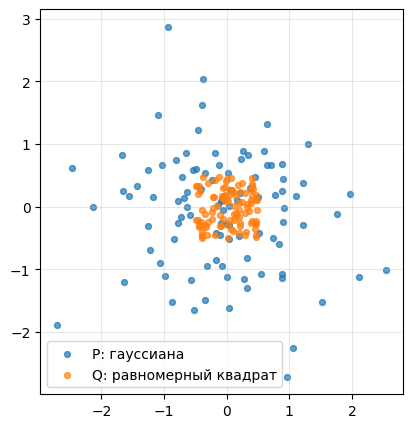

Evaluating k-NN precision and recall with 100 samples...
Evaluated k-NN precision and recall in: 0.00342774s


,гауссиана vs равномерный квадрат
mtd_PQ,1.6365
mtd_QP,0.9383
rtd,8.4073
mmd,0.4833
frechet,0.9073
js,0.5853
precision@1,0.6600
precision@3,0.9300
precision@10,1.0000
recall@1,0.2000


In [ ]:
P = sample_gaussian(100, seed=1)
Q = sample_uniform_cube(100, seed=2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(P[:, 0], P[:, 1], s=18, alpha=0.7, label='P: гауссиана')
ax.scatter(Q[:, 0], Q[:, 1], s=18, alpha=0.7, label='Q: равномерный квадрат')
ax.legend()
ax.set_aspect('equal')
ax.grid(alpha=0.3)
plt.show()

base_task = pd.Series(metrics.compute_all(P, Q), name='гауссиана vs равномерный квадрат')
display(base_task.to_frame().round(4))


## 3. Синтетические эксперименты

Нумерация — из переписки. Общий дизайн:

- **P — «данные» (seed 42), Q — «модель» (seed 7)**: облака всегда семплируются независимо (задача № 9 — никаких копий);
- деформация применяется к модельному облаку (в 3б — к данным), шаг за шагом; противое облако фиксировано;
- на шаге 0 оба облака — выборки одного закона: значения метрик там = уровень шума сэмплирования (§ 2.3), динамику смотрим относительно него;
- в экспериментах со смесью модель пересемплируется на каждом шаге с тем же сидом (метод общих случайных чисел) — траектории гладкие и реагируют только на `radius`.

| № | Эксперимент | Данные (P) | Модель (Q) | Деформация |
|---|---|---|---|---|
| 1 | кольцо → кольцо | кольцо | кольцо | сдвиг по x, 25 шагов |
| 2а | данные — диск | диск | кольцо | сдвиг по x, 25 шагов |
| 2б | данные — кольцо | кольцо | диск | сдвиг по x, 25 шагов |
| 3а | данные — гауссиана | $N(0,I)$ | смесь, $k=4$ | `radius` 0 → 1.4, 15 шагов |
| 3б | данные — смесь | смесь, $k=4$ | $N(0,I)$ | `radius` 0 → 1.4, 15 шагов |
| 4 | число компонент | $N(0,I)$ | смесь, $k$ = 4 / 8 / 16 | `radius` 0 → 1.4, 15 шагов |

**Что здесь интересно:** в 3а/3б смесь раздвигается *с сохранением глобальных моментов* — mean и covariance остаются как у $N(0,I)$ на всех шагах. Значит, Fréchet distance (и классический FID) такой деформации почти не видит, а топологические метрики и precision/recall — видят. Это яркая иллюстрация того, что разные метрики измеряют разное.

**RTD не видит сдвиги.** В экспериментах 1, 2а, 2б траектория RTD — константа (с точностью до шума подсэмплирования). Это свойство, а не баг: матрица для баркода RTD строится только из *внутренних* попарных расстояний каждого облака (без cross-расстояний), поэтому RTD инвариантен к независимым движениям (сдвигам/поворотам) каждого из облаков. Сдвиг он «увидит» только если тот изменит внутреннюю структуру — например, когда часть кольца-model выходит за пределы диска и её плотность меняется. Зато во внутренние деформации (эксперименты 3а/3б/4 — раздвигание смеси) RTD видит отлично. Получается удобная система: сдвиговые эксперименты дискриминируют метрики по инвариантности, эксперименты со смесью — по типу «зрения» (локальная структура vs глобальные моменты).

> **Время выполнения:** весь § 3 — примерно 50–70 минут на T4. Замер на 1000+1000 точек: RTD с 5 усредлениями ≈ 17 c (основная стоимость — 10 запусков ripser++ на вызов `compute_all`), MTD в обе стороны ≈ 3 c, improved PR ≈ 1.2 c, статистические метрики ≈ 0.1 c. Прогресс виден по шагам (tqdm). Точнее/дороже — `compute_all(..., rtd_trials=10)`, быстрее — `rtd_trials=2`.


In [ ]:
DISTANCE_METRICS = ['mtd_PQ', 'mtd_QP', 'rtd', 'mmd', 'frechet', 'js']
SIMILARITY_METRICS = [
    'precision@1', 'precision@3', 'precision@10',
    'recall@1', 'recall@3', 'recall@10',
]

SEED_DATA, SEED_MODEL = 42, 7
N_POINTS = 1000


def constant_cloud(cloud):
    return lambda step: cloud


def translated_cloud(cloud, eps):
    """Сдвиг облака на eps * step вдоль оси x."""
    return lambda step: cloud + np.array([eps * step, 0.0])


def run_experiment(name, data_fn, model_fn, n_steps, extra=None):
    """Все метрики на каждом шаге; data_fn/model_fn(step) -> облако точек."""
    rows = []
    for step in tqdm(range(n_steps), desc=name):
        row = {'experiment': name, 'step': step}
        if extra is not None:
            row.update(extra)
        row.update(metrics.compute_all(data_fn(step), model_fn(step)))
        rows.append(row)
    return pd.DataFrame(rows)


def show_steps(n_steps, n=5):
    return np.linspace(0, n_steps - 1, n).astype(int)


def plot_clouds(data_fn, model_fn, steps, title=''):
    steps = np.atleast_1d(steps)
    fig, axes = plt.subplots(1, len(steps), figsize=(3.8 * len(steps), 3.8), squeeze=False)
    for ax, step in zip(axes[0], steps):
        P, Q = data_fn(step), model_fn(step)
        ax.scatter(P[:, 0], P[:, 1], s=6, alpha=0.6, label='P (данные)')
        ax.scatter(Q[:, 0], Q[:, 1], s=6, alpha=0.6, label='Q (модель)')
        ax.set_title(f'шаг {step}', fontsize=10)
        ax.set_aspect('equal')
        ax.legend(fontsize=7, loc='upper right')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_trajectories(df, title=''):
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
    for ax, metric in zip(axes.flat, DISTANCE_METRICS):
        ax.plot(df['step'], df[metric], marker='.', markersize=4)
        ax.set_title(metric)
        ax.set_xlabel('шаг')
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    precisions = [m for m in SIMILARITY_METRICS if m.startswith('precision')]
    recalls = [m for m in SIMILARITY_METRICS if m.startswith('recall')]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for metric in precisions:
        axes[0].plot(df['step'], df[metric], marker='.', markersize=4, label=metric)
    for metric in recalls:
        axes[1].plot(df['step'], df[metric], marker='.', markersize=4, label=metric)
    for ax, label in zip(axes, ('precision', 'recall')):
        ax.set_title(label)
        ax.set_xlabel('шаг')
        ax.set_ylim(-0.02, 1.05)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


### 3.1. Эксперимент 1 — кольцо → кольцо (сдвиг)

Два кольца одного закона; модель сдвигается по x на 0.2 за шаг (за 25 шагов — на полный радиус). Ожидаем: рост MTD/MMD/Fréchet/JS и падение precision/recall; на шаге 0 — уровень шума сэмплирования. **RTD остается константой** — инвариантен к сдвигу (см. замечание выше).


эксп. 1: кольцо vs кольцо, сдвиг:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0753932s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0920119s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0766711s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.135122s


...

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.125233s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0760992s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0757315s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0752599s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0813396s


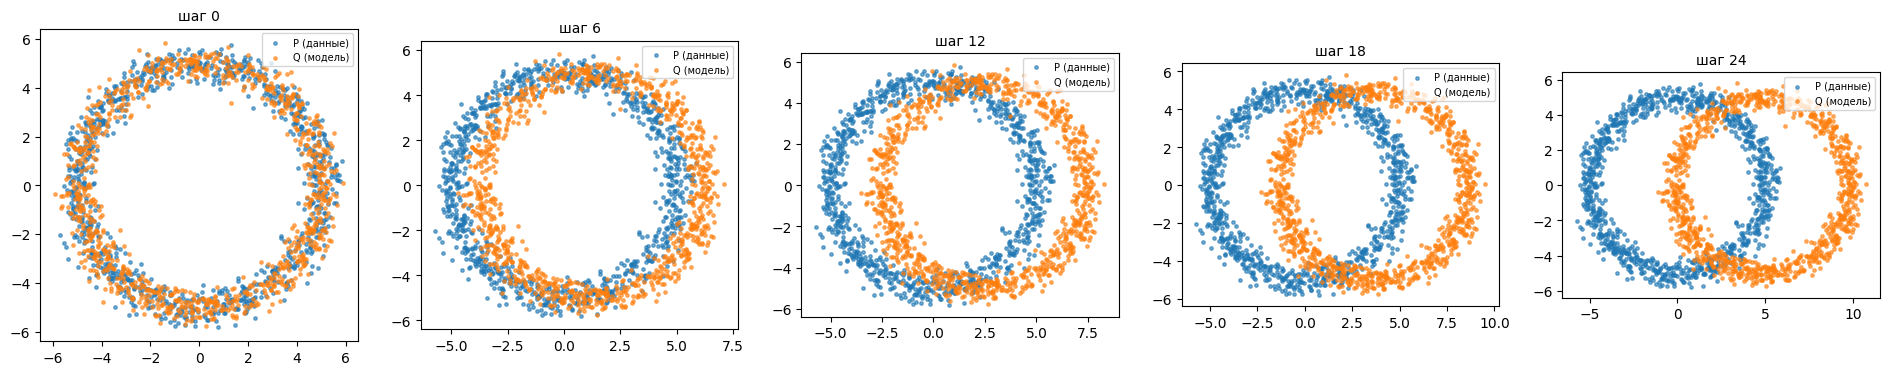

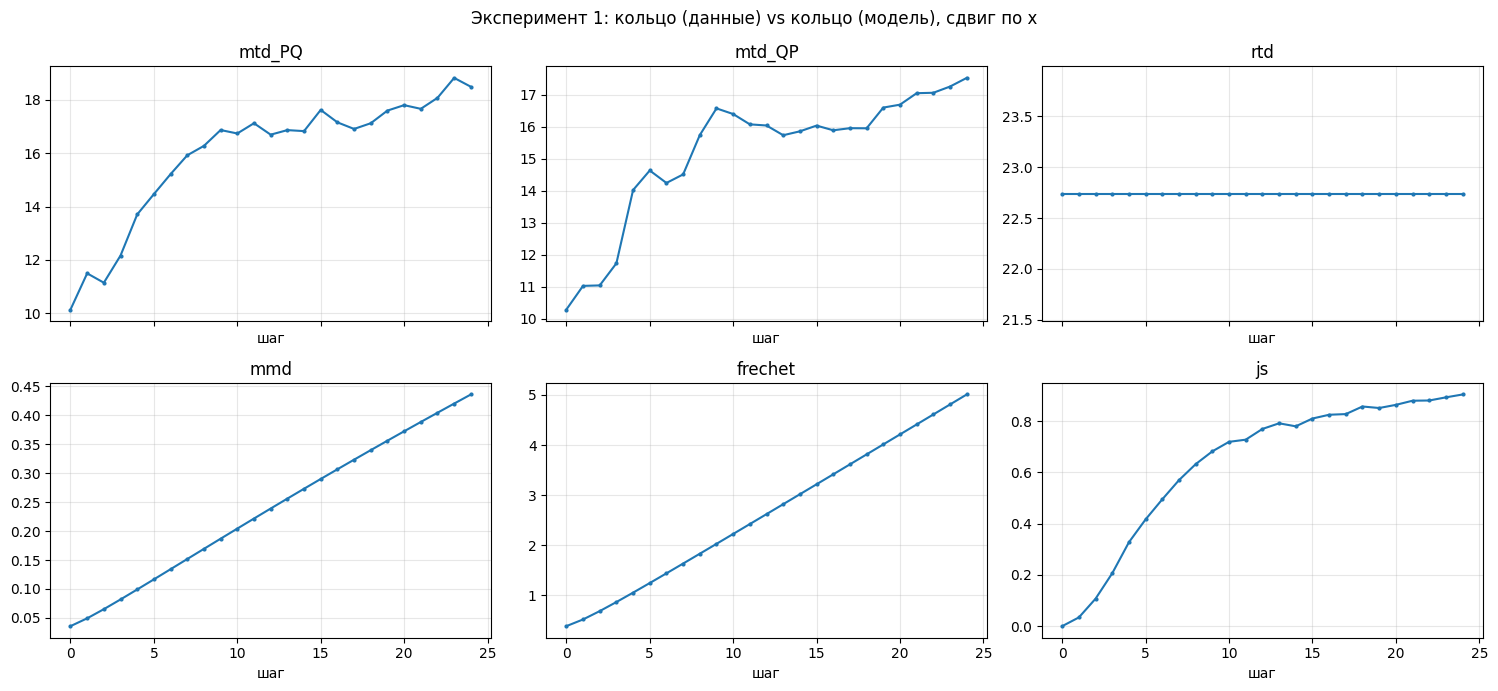

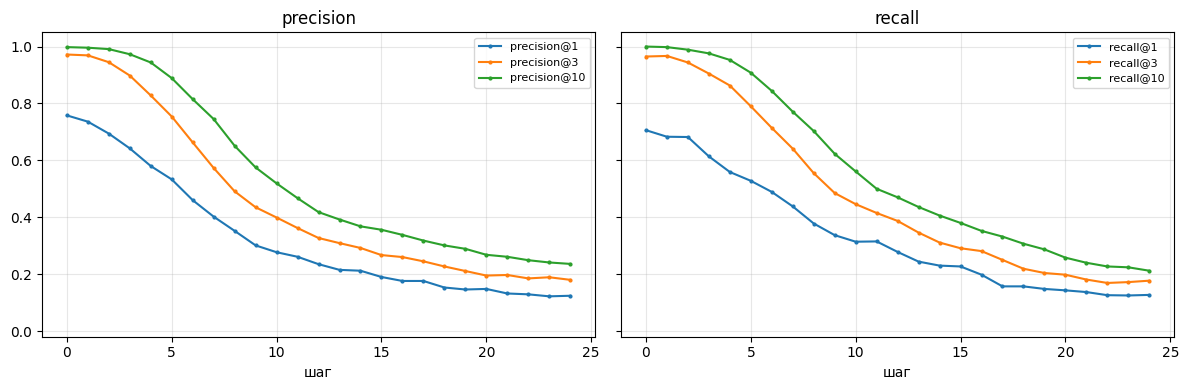

,experiment,step,mtd_PQ,mtd_QP,rtd,mmd,frechet,js,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10
0,"эксп. 1: кольцо vs кольцо, сдвиг",0,10.1373,10.2882,22.7384,0.0358,0.3813,0.0000,0.758,0.972,0.998,0.706,0.965,1.000
1,"эксп. 1: кольцо vs кольцо, сдвиг",1,11.4961,11.0279,22.7384,0.0493,0.5148,0.0341,0.736,0.969,0.996,0.683,0.967,0.998
2,"эксп. 1: кольцо vs кольцо, сдвиг",2,11.1447,11.0424,22.7384,0.0651,0.6816,0.1072,0.694,0.945,0.991,0.682,0.944,0.989
3,"эксп. 1: кольцо vs кольцо, сдвиг",3,12.1643,11.7328,22.7384,0.0819,0.8627,0.2065,0.642,0.898,0.973,0.614,0.905,0.976
4,"эксп. 1: кольцо vs кольцо, сдвиг",4,13.7064,14.0196,22.7384,0.0992,1.0506,0.3275,0.580,0.828,0.944,0.559,0.863,0.953
5,"эксп. 1: кольцо vs кольцо, сдвиг",5,14.4685,14.6300,22.7384,0.1166,1.2424,0.4167,0.533,0.754,0.889,0.528,0.790,0.908
6,"эксп. 1: кольцо vs кольцо, сдвиг",6,15.2180,14.2409,22.7384,0.1342,1.4363,0.4950,0.460,0.663,0.815,0.489,0.714,0.844
7,"эксп. 1: кольцо vs кольцо, сдвиг",7,15.9244,14.5074,22.7384,0.1518,1.6318,0.5698,0.402,0.573,0.745,0.438,0.641,0.771
8,"эксп. 1: кольцо vs кольцо, сдвиг",8,16.2784,15.7347,22.7384,0.1693,1.8282,0.6322,0.352,0.491,0.651,0.378,0.555,0.703
9,"эксп. 1: кольцо vs кольцо, сдвиг",9,16.8720,16.5687,22.7384,0.1869,2.0253,0.6822,0.301,0.435,0.575,0.337,0.485,0.623


In [ ]:
ring_data = sample_ring(N_POINTS, radius=5.0, thickness=1.5, seed=SEED_DATA)
ring_model = sample_ring(N_POINTS, radius=5.0, thickness=1.5, seed=SEED_MODEL)

exp1 = run_experiment(
    'эксп. 1: кольцо vs кольцо, сдвиг',
    data_fn=constant_cloud(ring_data),
    model_fn=translated_cloud(ring_model, eps=0.2),
    n_steps=25,
)
plot_clouds(constant_cloud(ring_data), translated_cloud(ring_model, eps=0.2), show_steps(25))
plot_trajectories(exp1, 'Эксперимент 1: кольцо (данные) vs кольцо (модель), сдвиг по x')
exp1.round(4)


### 3.2. Эксперимент 2а — данные: диск, модель: кольцо (задача № 11)

Кольцо-модель уезжает из диска-данных. С самого начала recall низкий: центр диска не накрыт кольцом. Precision высокий, пока кольцо внутри диска, и падает, когда оно выходит за край.


эксп. 2а: диск (данные) vs кольцо (модель), сдвиг:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0793514s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0750721s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0896692s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.124353s


...

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.075814s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.075434s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0766101s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.138988s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0797472s


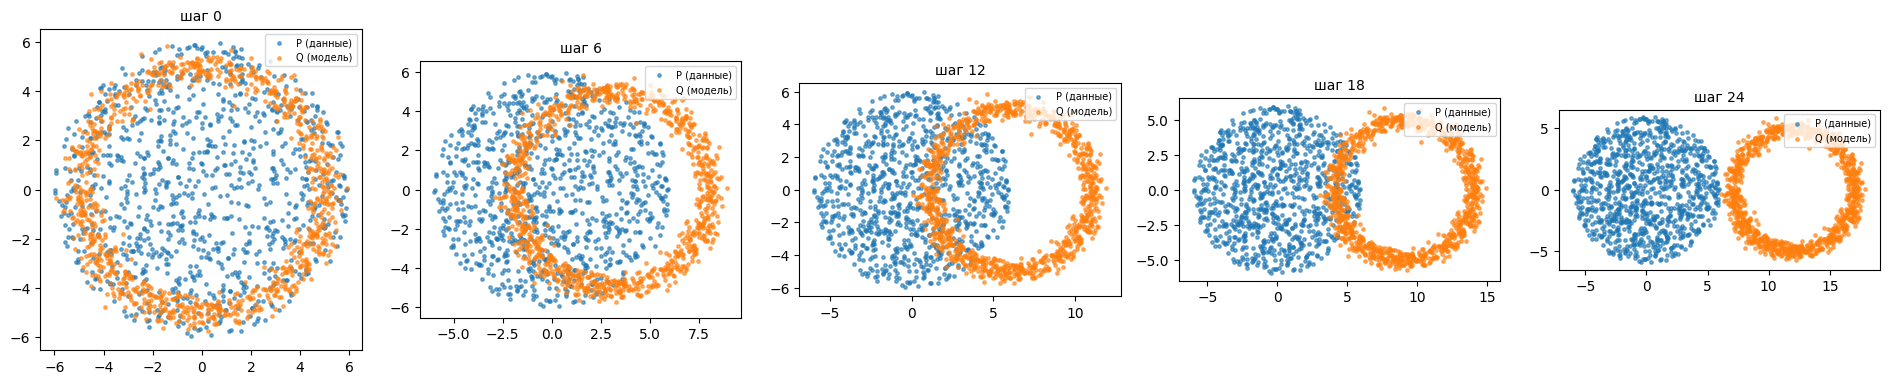

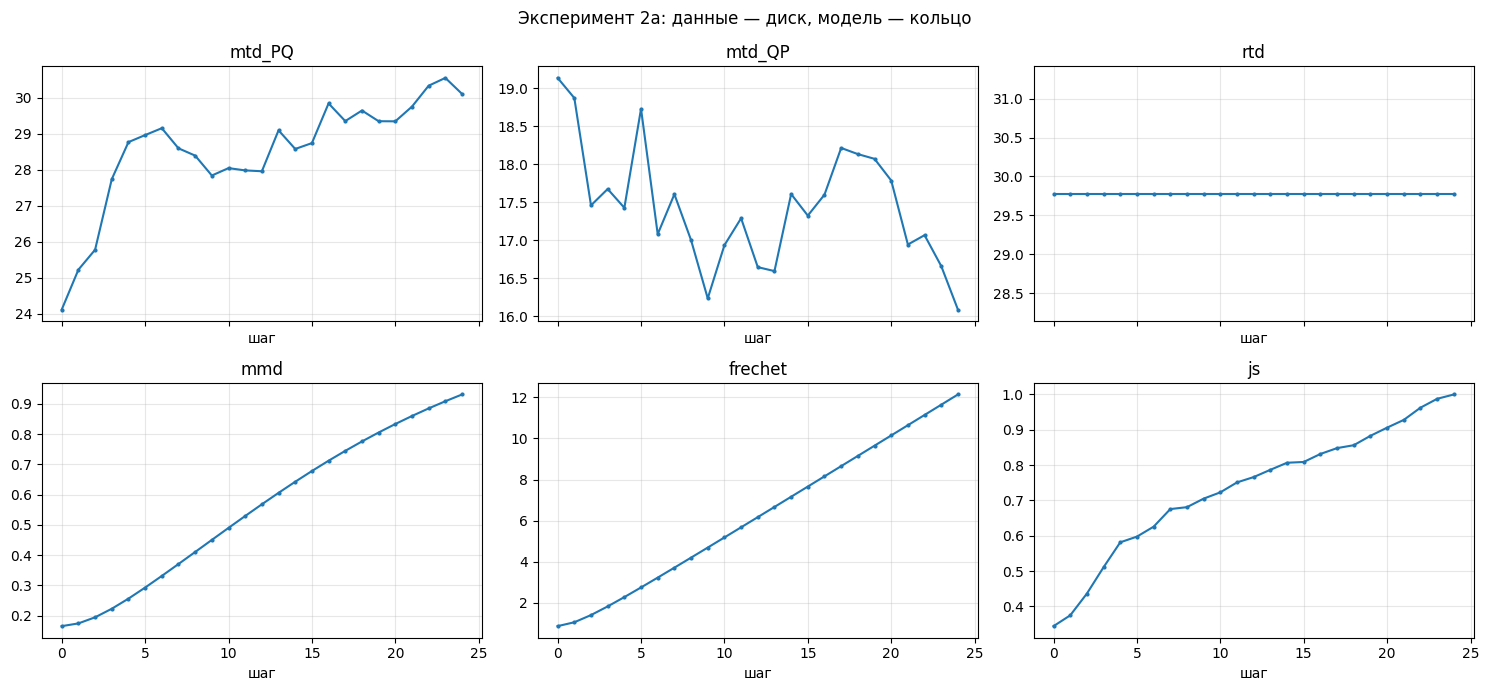

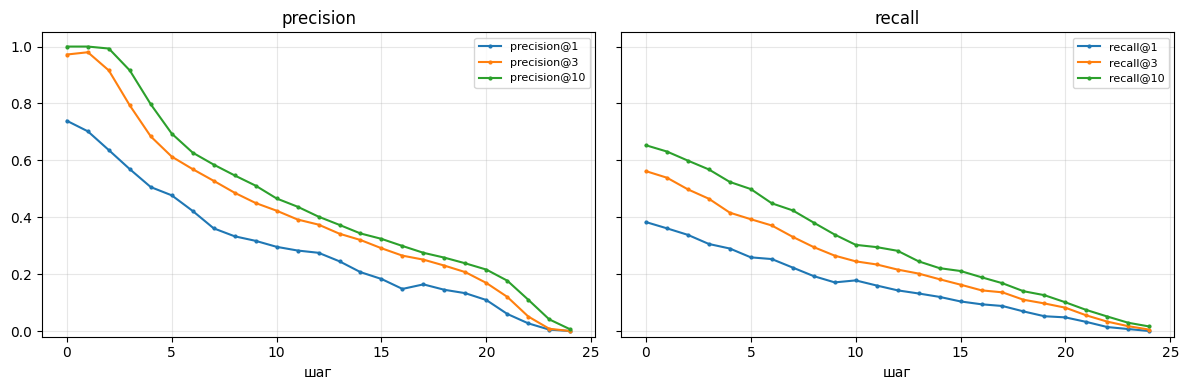

,experiment,step,mtd_PQ,mtd_QP,rtd,mmd,frechet,js,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10
0,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",0,24.1185,19.1347,29.7774,0.1653,0.8668,0.3445,0.739,0.972,1.000,0.383,0.562,0.653
1,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",1,25.2263,18.8705,29.7774,0.1743,1.0551,0.3750,0.702,0.980,1.000,0.361,0.539,0.631
2,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",2,25.7793,17.4591,29.7774,0.1945,1.4054,0.4365,0.636,0.916,0.993,0.338,0.498,0.599
3,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",3,27.7381,17.6740,29.7774,0.2228,1.8268,0.5111,0.569,0.793,0.916,0.306,0.465,0.568
4,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",4,28.7676,17.4269,29.7774,0.2562,2.2801,0.5814,0.506,0.684,0.797,0.290,0.416,0.524
5,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",5,28.9630,18.7283,29.7774,0.2928,2.7497,0.5976,0.477,0.613,0.694,0.259,0.393,0.499
6,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",6,29.1541,17.0802,29.7774,0.3312,3.2284,0.6257,0.422,0.569,0.627,0.253,0.371,0.449
7,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",7,28.5954,17.6056,29.7774,0.3706,3.7128,0.6755,0.361,0.528,0.585,0.223,0.331,0.424
8,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",8,28.3929,17.0015,29.7774,0.4105,4.2008,0.6809,0.333,0.486,0.547,0.193,0.295,0.381
9,"эксп. 2а: диск (данные) vs кольцо (модель), сдвиг",9,27.8404,16.2359,29.7774,0.4503,4.6913,0.7050,0.317,0.450,0.511,0.171,0.265,0.339


In [ ]:
disk_data = sample_ball(N_POINTS, radius=6.0, seed=SEED_DATA)

exp2a = run_experiment(
    'эксп. 2а: диск (данные) vs кольцо (модель), сдвиг',
    data_fn=constant_cloud(disk_data),
    model_fn=translated_cloud(ring_model, eps=0.5),
    n_steps=25,
)
plot_clouds(constant_cloud(disk_data), translated_cloud(ring_model, eps=0.5), show_steps(25))
plot_trajectories(exp2a, 'Эксперимент 2а: данные — диск, модель — кольцо')
exp2a.round(4)


### 3.3. Эксперимент 2б — данные: кольцо, модель: диск (задача № 11)

Зеркально 2а: диск-модель уезжает из кольца-данных. Теперь наоборот — precision низкий с начала (центр диска-модели не совпадает с кольцом-данными), recall высокий, пока диск накрывает кольцо.


эксп. 2б: кольцо (данные) vs диск (модель), сдвиг:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0781646s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.125247s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0863476s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0779989s


...

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0772204s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0787246s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0803268s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0795023s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0824516s


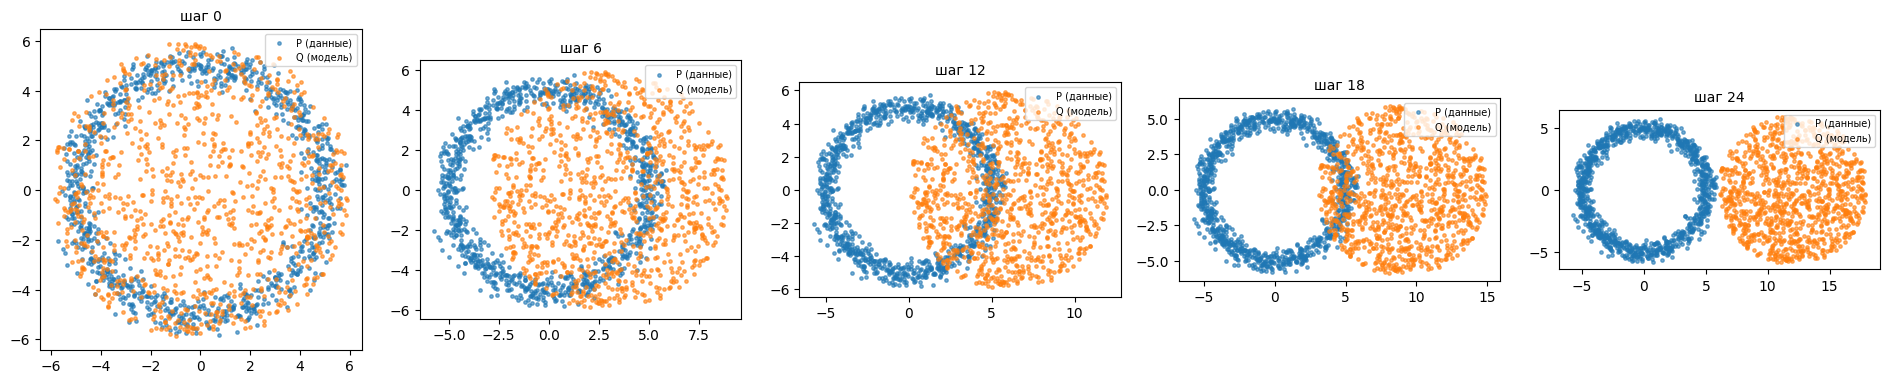

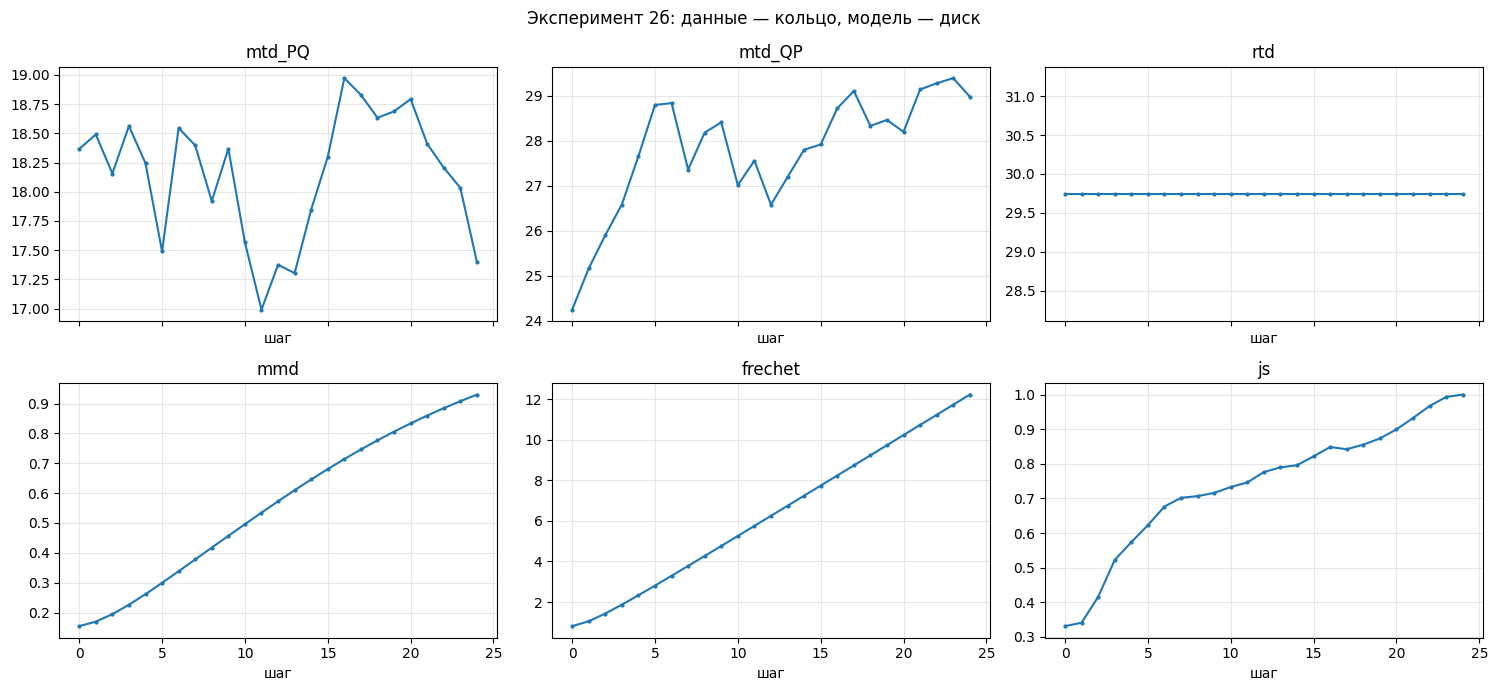

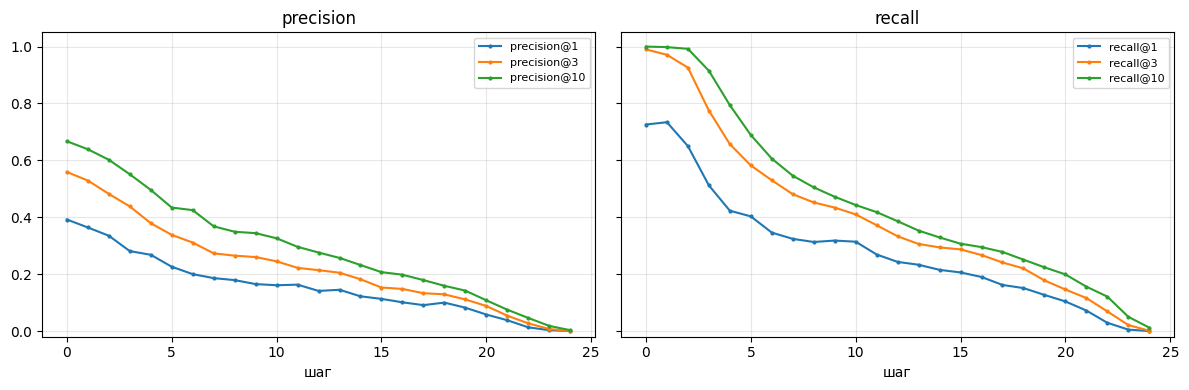

,experiment,step,mtd_PQ,mtd_QP,rtd,mmd,frechet,js,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10
0,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",0,18.3662,24.2422,29.7432,0.1546,0.8105,0.3311,0.392,0.559,0.667,0.726,0.990,1.000
1,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",1,18.4900,25.1585,29.7432,0.1696,1.0499,0.3411,0.364,0.529,0.639,0.734,0.971,0.998
2,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",2,18.1560,25.8966,29.7432,0.1947,1.4310,0.4157,0.335,0.482,0.602,0.650,0.926,0.992
3,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",3,18.5623,26.5791,29.7432,0.2263,1.8690,0.5224,0.281,0.438,0.551,0.512,0.775,0.915
4,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",4,18.2432,27.6518,29.7432,0.2618,2.3321,0.5737,0.268,0.379,0.496,0.423,0.657,0.794
5,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",5,17.4889,28.7913,29.7432,0.2995,2.8079,0.6227,0.226,0.338,0.434,0.403,0.582,0.689
6,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",6,18.5451,28.8313,29.7432,0.3385,3.2908,0.6766,0.200,0.311,0.425,0.346,0.530,0.606
7,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",7,18.3958,27.3555,29.7432,0.3779,3.7782,0.7019,0.186,0.273,0.368,0.324,0.481,0.546
8,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",8,17.9198,28.1786,29.7432,0.4175,4.2685,0.7068,0.179,0.265,0.349,0.313,0.452,0.505
9,"эксп. 2б: кольцо (данные) vs диск (модель), сдвиг",9,18.3681,28.4041,29.7432,0.4569,4.7609,0.7161,0.165,0.260,0.344,0.318,0.434,0.472


In [ ]:
disk_model = sample_ball(N_POINTS, radius=6.0, seed=SEED_MODEL)

exp2b = run_experiment(
    'эксп. 2б: кольцо (данные) vs диск (модель), сдвиг',
    data_fn=constant_cloud(ring_data),
    model_fn=translated_cloud(disk_model, eps=0.5),
    n_steps=25,
)
plot_clouds(constant_cloud(ring_data), translated_cloud(disk_model, eps=0.5), show_steps(25))
plot_trajectories(exp2b, 'Эксперимент 2б: данные — кольцо, модель — диск')
exp2b.round(4)


### 3.4. Эксперимент 3а — данные: гауссиана, модель: раздвигающаяся смесь (задача № 12)

Смесь-модель раздвигается от $N(0,I)$ (radius = 0) до почти разделенных компонент (radius = 1.4), глобальные mean/cov не меняются. Ключевой момент: **Fréchet distance почти не видит деформацию** (считает по моментам), а топологические метрики и PR — видят.


эксп. 3а: гауссиана (данные) vs раздвигающаяся смесь (модель):   0%|          | 0/15 [00:00<?, ?it/s]

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0726042s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0946825s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0779378s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0799534s


...

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.123226s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0783343s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.076282s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0782819s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0750558s


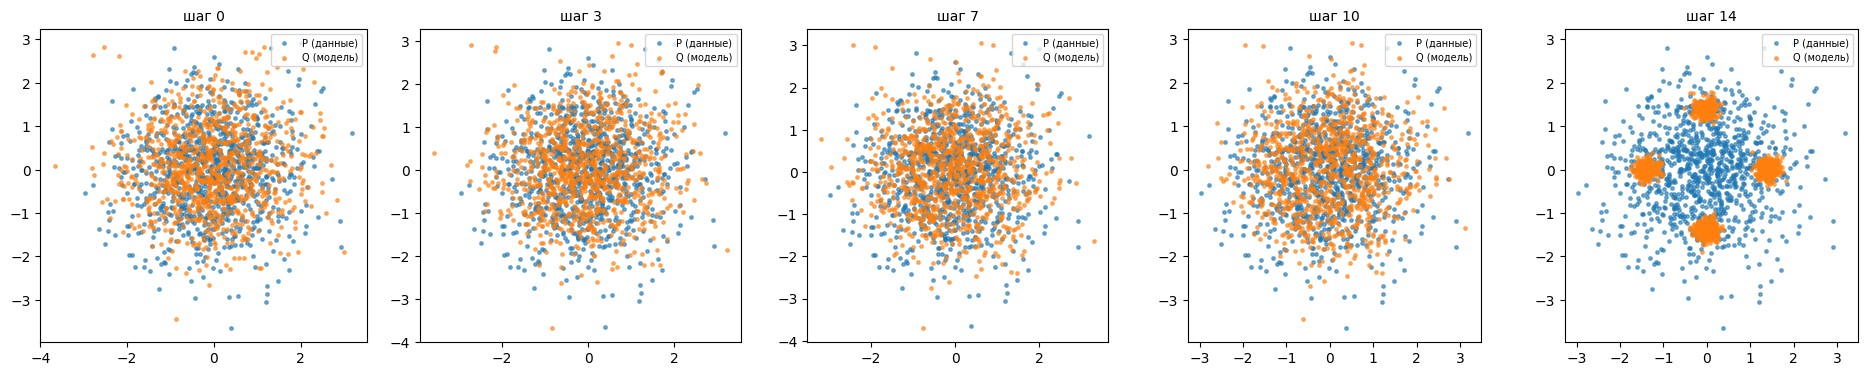

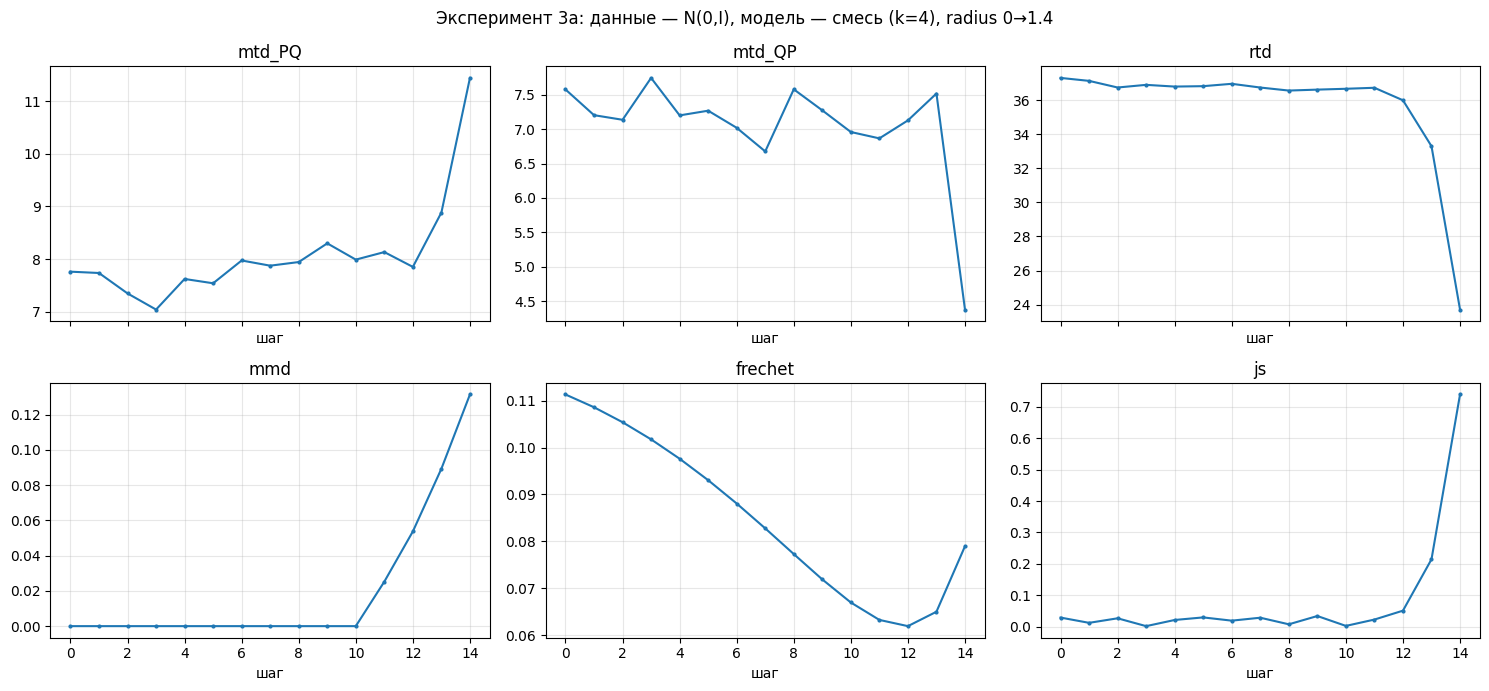

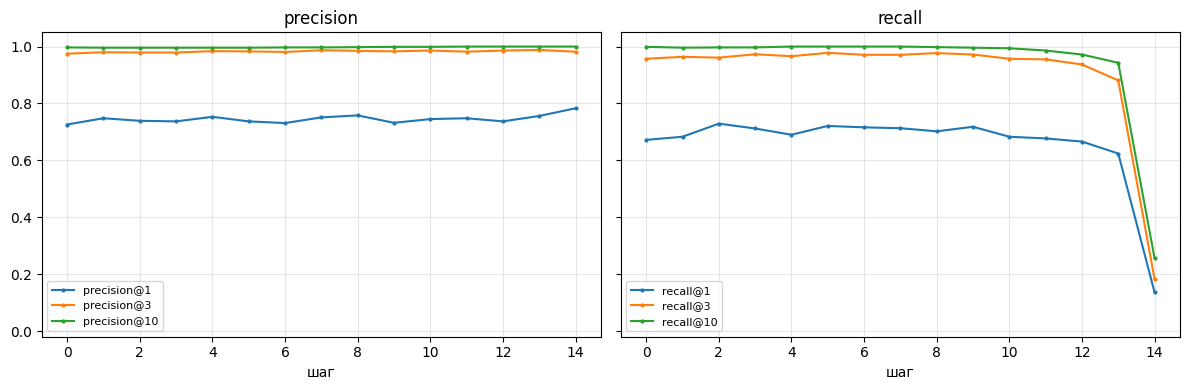

,experiment,step,mtd_PQ,mtd_QP,rtd,mmd,frechet,js,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10
0,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,0,7.7626,7.5752,37.3119,0.0000,0.1113,0.0288,0.726,0.975,0.997,0.672,0.957,0.999
1,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,1,7.7374,7.2019,37.1381,0.0000,0.1086,0.0120,0.748,0.980,0.996,0.683,0.964,0.996
2,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,2,7.3501,7.1351,36.7486,0.0000,0.1054,0.0265,0.739,0.979,0.996,0.729,0.961,0.997
3,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,3,7.0431,7.7427,36.9044,0.0000,0.1018,0.0015,0.737,0.979,0.996,0.712,0.973,0.997
4,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,4,7.6240,7.1987,36.8034,0.0000,0.0976,0.0211,0.753,0.984,0.996,0.690,0.966,1.000
5,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,5,7.5423,7.2669,36.8273,0.0000,0.0931,0.0293,0.737,0.983,0.996,0.721,0.978,1.000
6,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,6,7.9749,7.0184,36.9655,0.0000,0.0881,0.0190,0.731,0.981,0.997,0.716,0.971,1.000
7,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,7,7.8762,6.6759,36.7471,0.0000,0.0828,0.0283,0.751,0.987,0.997,0.713,0.971,1.000
8,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,8,7.9452,7.5772,36.5692,0.0000,0.0773,0.0074,0.758,0.985,0.998,0.702,0.977,0.998
9,эксп. 3а: гауссиана (данные) vs раздвигающаяся...,9,8.3002,7.2717,36.6246,0.0000,0.0719,0.0337,0.732,0.983,0.999,0.718,0.972,0.996


In [ ]:
gaussian_data = sample_gaussian(N_POINTS, seed=SEED_DATA)

def mixture_model(step, n_components=4):
    return sample_gaussian_mixture(N_POINTS, radius=0.1 * step, n_components=n_components, seed=SEED_MODEL)

exp3a = run_experiment(
    'эксп. 3а: гауссиана (данные) vs раздвигающаяся смесь (модель)',
    data_fn=constant_cloud(gaussian_data),
    model_fn=mixture_model,
    n_steps=15,
)
plot_clouds(constant_cloud(gaussian_data), mixture_model, show_steps(15))
plot_trajectories(exp3a, 'Эксперимент 3а: данные — N(0,I), модель — смесь (k=4), radius 0→1.4')
exp3a.round(4)


### 3.5. Эксперимент 3б — данные: раздвигающаяся смесь, модель: гауссиана (задача № 12)

Зеркально 3а: теперь раздвигаются данные, модель-гауссиана фиксирована. Сравнение траекторий 3а и 3б показывает, насколько метрики асимметричны: у симметричных (rtd, mmd, frechet, js) траектории совпадают с точностью до шума, у MTD направления и precision/recall различаются.


эксп. 3б: раздвигающаяся смесь (данные) vs гауссиана (модель):   0%|          | 0/15 [00:00<?, ?it/s]

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0763276s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.123543s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0727675s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0771012s


...

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0759475s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0808721s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0784459s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0826702s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.117455s


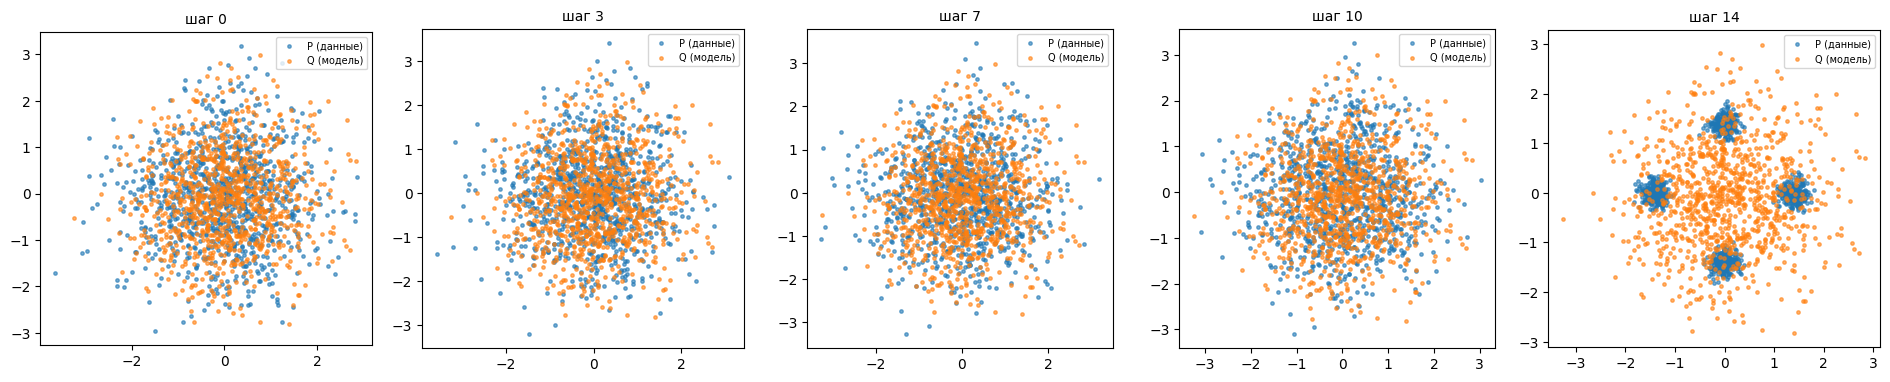

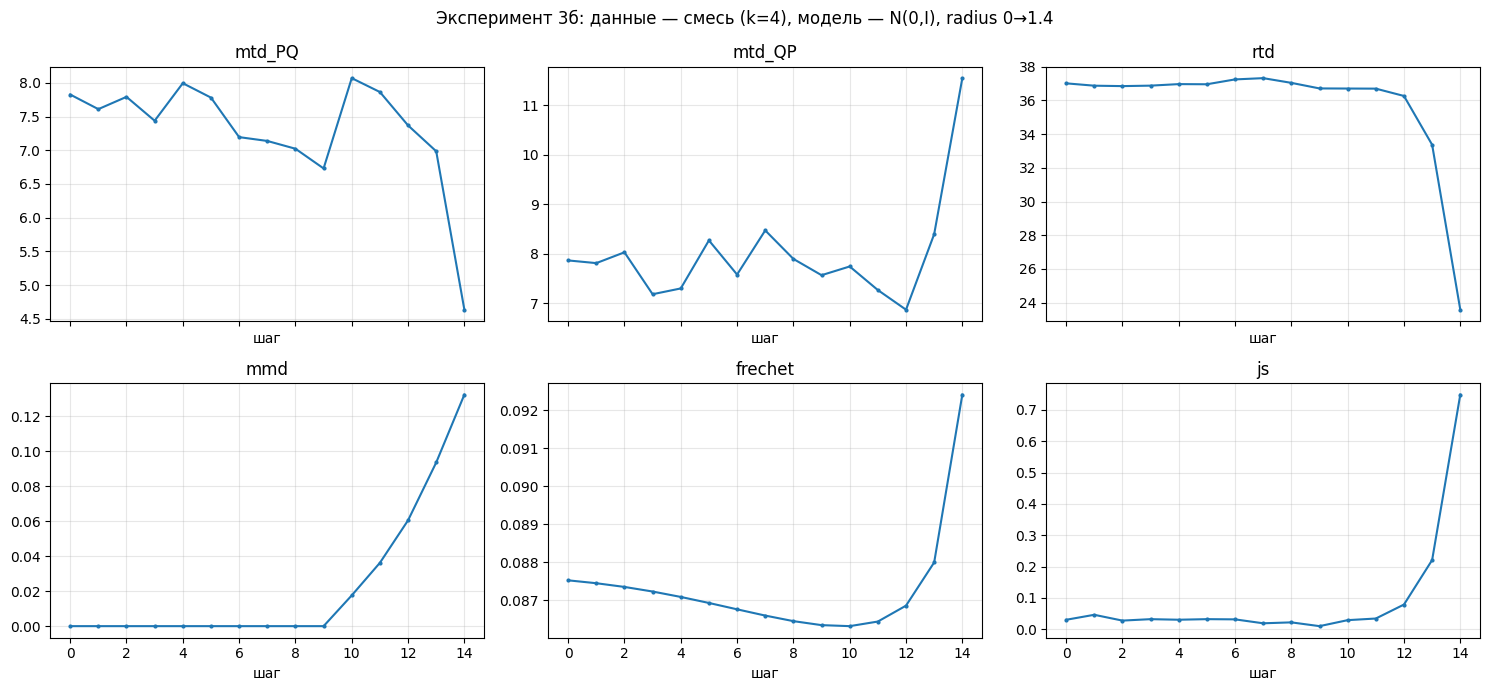

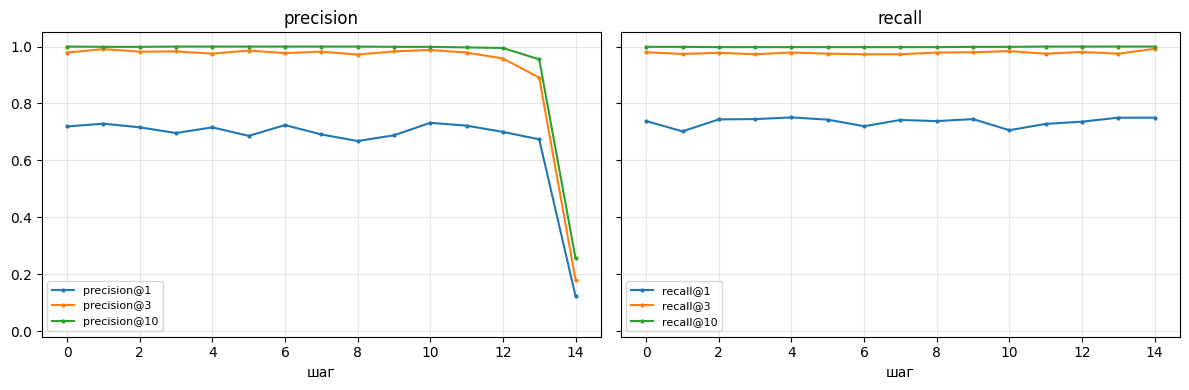

,experiment,step,mtd_PQ,mtd_QP,rtd,mmd,frechet,js,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10
0,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,0,7.8279,7.8682,37.0167,0.0000,0.0875,0.0302,0.719,0.979,1.000,0.738,0.980,0.999
1,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,1,7.6109,7.8139,36.8772,0.0000,0.0874,0.0462,0.729,0.991,0.999,0.702,0.974,0.999
2,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,2,7.7932,8.0325,36.8521,0.0000,0.0873,0.0277,0.716,0.982,0.999,0.744,0.978,0.998
3,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,3,7.4388,7.1852,36.8800,0.0000,0.0872,0.0322,0.696,0.983,1.000,0.745,0.973,0.998
4,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,4,7.9958,7.3021,36.9709,0.0000,0.0871,0.0305,0.716,0.975,1.000,0.751,0.979,0.998
5,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,5,7.7820,8.2730,36.9617,0.0000,0.0869,0.0323,0.686,0.986,1.000,0.743,0.975,0.998
6,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,6,7.1955,7.5827,37.2500,0.0000,0.0868,0.0316,0.724,0.977,1.000,0.720,0.973,0.998
7,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,7,7.1387,8.4751,37.3252,0.0000,0.0866,0.0191,0.691,0.982,1.000,0.742,0.973,0.998
8,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,8,7.0233,7.8988,37.0451,0.0000,0.0864,0.0220,0.668,0.972,1.000,0.738,0.979,0.998
9,эксп. 3б: раздвигающаяся смесь (данные) vs гау...,9,6.7309,7.5698,36.7145,0.0000,0.0863,0.0100,0.688,0.983,0.999,0.745,0.980,0.999


In [ ]:
def mixture_data(step, n_components=4):
    return sample_gaussian_mixture(N_POINTS, radius=0.1 * step, n_components=n_components, seed=SEED_DATA)

gaussian_model = sample_gaussian(N_POINTS, seed=SEED_MODEL)

exp3b = run_experiment(
    'эксп. 3б: раздвигающаяся смесь (данные) vs гауссиана (модель)',
    data_fn=mixture_data,
    model_fn=constant_cloud(gaussian_model),
    n_steps=15,
)
plot_clouds(mixture_data, constant_cloud(gaussian_model), show_steps(15))
plot_trajectories(exp3b, 'Эксперимент 3б: данные — смесь (k=4), модель — N(0,I), radius 0→1.4')
exp3b.round(4)


### 3.6. Эксперимент 4 — число компонент смеси (задача № 13)

Тот же сценарий, что 3а, но $k$ = 4 / 8 / 16. Научрук просил сделать число компонент параметром («сейчас 4, а можно было бы 8»). Смотрим, как растет «чувствительность» метрик к раздвиганию при большем числе компонент.


эксп. 4: смесь 4 компонент:   0%|          | 0/15 [00:00<?, ?it/s]

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.126794s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0743182s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0765944s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0765529s


...

Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0797977s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0758474s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0746291s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0790169s


Evaluating k-NN precision and recall with 1000 samples...
Evaluated k-NN precision and recall in: 0.0869539s


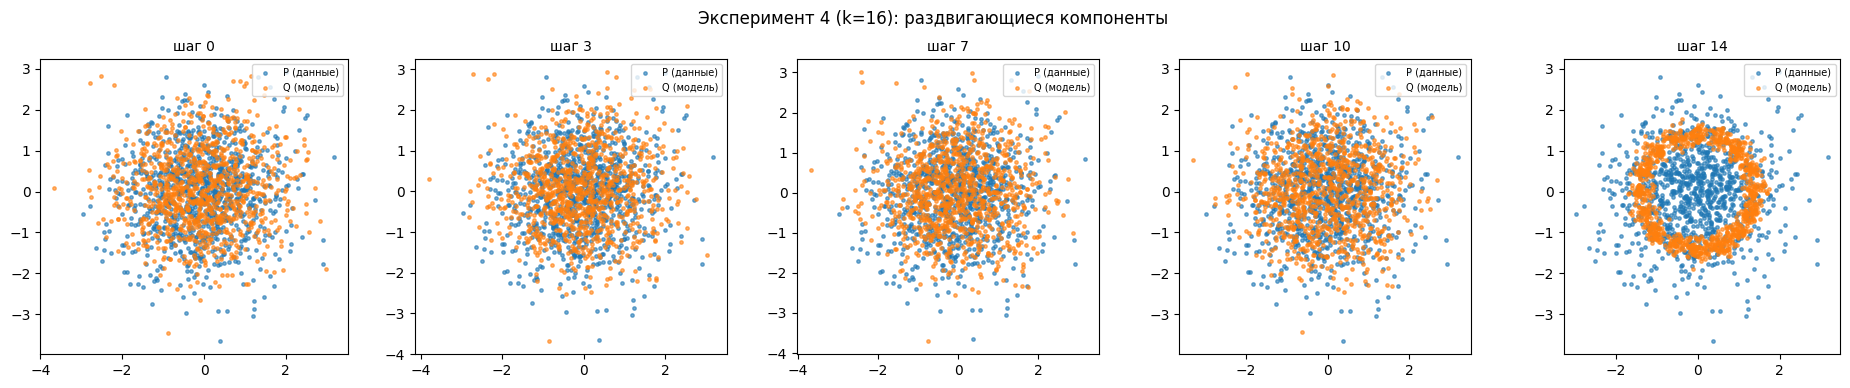

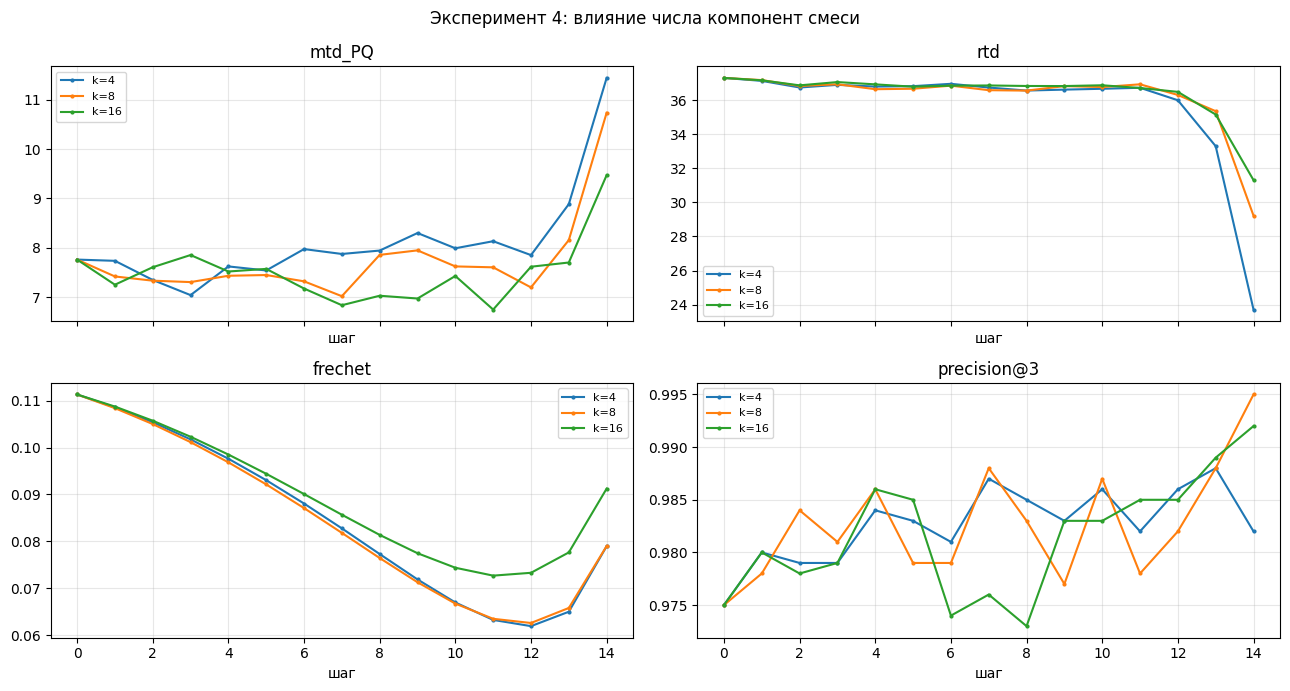

,experiment,step,n_components,mtd_PQ,mtd_QP,rtd,mmd,frechet,js,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10
0,эксп. 4: смесь 4 компонент,0,4,7.7626,7.5752,37.3119,0.0000,0.1113,0.0288,0.726,0.975,0.997,0.672,0.957,0.999
1,эксп. 4: смесь 4 компонент,1,4,7.7374,7.2019,37.1381,0.0000,0.1086,0.0120,0.748,0.980,0.996,0.683,0.964,0.996
2,эксп. 4: смесь 4 компонент,2,4,7.3501,7.1351,36.7486,0.0000,0.1054,0.0265,0.739,0.979,0.996,0.729,0.961,0.997
3,эксп. 4: смесь 4 компонент,3,4,7.0431,7.7427,36.9044,0.0000,0.1018,0.0015,0.737,0.979,0.996,0.712,0.973,0.997
4,эксп. 4: смесь 4 компонент,4,4,7.6240,7.1987,36.8034,0.0000,0.0976,0.0211,0.753,0.984,0.996,0.690,0.966,1.000
5,эксп. 4: смесь 4 компонент,5,4,7.5423,7.2669,36.8273,0.0000,0.0931,0.0293,0.737,0.983,0.996,0.721,0.978,1.000
6,эксп. 4: смесь 4 компонент,6,4,7.9749,7.0184,36.9655,0.0000,0.0881,0.0190,0.731,0.981,0.997,0.716,0.971,1.000
7,эксп. 4: смесь 4 компонент,7,4,7.8762,6.6759,36.7471,0.0000,0.0828,0.0283,0.751,0.987,0.997,0.713,0.971,1.000
8,эксп. 4: смесь 4 компонент,8,4,7.9452,7.5772,36.5692,0.0000,0.0773,0.0074,0.758,0.985,0.998,0.702,0.977,0.998
9,эксп. 4: смесь 4 компонент,9,4,8.3002,7.2717,36.6246,0.0000,0.0719,0.0337,0.732,0.983,0.999,0.718,0.972,0.996


In [ ]:
exp4 = pd.concat(
    [
        run_experiment(
            f'эксп. 4: смесь {k} компонент',
            data_fn=constant_cloud(gaussian_data),
            model_fn=lambda step, k=k: mixture_model(step, n_components=k),
            n_steps=15,
            extra={'n_components': k},
        )
        for k in (4, 8, 16)
    ],
    ignore_index=True,
)

plot_clouds(
    constant_cloud(gaussian_data),
    lambda step: mixture_model(step, n_components=16),
    show_steps(15),
    title='Эксперимент 4 (k=16): раздвигающиеся компоненты',
)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for metric, ax in zip(['mtd_PQ', 'rtd', 'frechet', 'precision@3'], axes.flat):
    for k, part in exp4.groupby('n_components'):
        ax.plot(part['step'], part[metric], marker='.', markersize=4, label=f'k={k}')
    ax.set_title(metric)
    ax.set_xlabel('шаг')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Эксперимент 4: влияние числа компонент смеси')
plt.tight_layout()
plt.show()
exp4.round(4)


## 4. Корреляционный анализ метрик (задача № 14)

Гипотеза научрука: *precision/recall-метрики должны быть больше похожи между собой, чем с симметричными, и наоборот — тоже для симметричных.*

Метод: в каждом эксперименте § 3 — корреляции Спирмена между траекториями метрик (по шагам), усредненные по экспериментам. Перед этим precision/recall инвертируются ($1 - x$), чтобы все метрики были «расходимостями» и знак корреляции имел единый смысл. Константные траектории отбрасываются (корреляция не определена): так RTD выпадает из сдвиговых экспериментов, Fréchet — из экспериментов со смесью.

Группы:
- **precision/recall** — `precision@k`, `recall@k` (асимметричные, локальное покрытие);
- **симметричные** — rtd, mmd, frechet, js;
- **асимметричные топологические** — `mtd_PQ`, `mtd_QP`.


In [ ]:
METRIC_GROUPS = {
    'precision/recall': SIMILARITY_METRICS,
    'симметричные': ['rtd', 'mmd', 'frechet', 'js'],
    'асимм. топологические': ['mtd_PQ', 'mtd_QP'],
}

ALL_METRICS = [m for metrics in METRIC_GROUPS.values() for m in metrics]


def trajectories_correlation(df):
    """Средняя по экспериментам корреляция Спирмена между траекториями метрик.

    PR-метрики инвертируются (1 - x); константные траектории отбрасываются.
    """
    inverted = df.copy()
    pr_cols = [c for c in inverted.columns if c.startswith(('precision', 'recall'))]
    inverted[pr_cols] = 1.0 - inverted[pr_cols]

    matrices = []
    for _, part in inverted.groupby('experiment'):
        usable = [m for m in ALL_METRICS if m in part.columns and part[m].nunique() > 1]
        if len(part) < 4 or len(usable) < 2:
            continue
        corr = part[usable].corr(method='spearman').reindex(index=ALL_METRICS, columns=ALL_METRICS)
        matrices.append(corr.values)
    averaged = np.nanmean(np.stack(matrices), axis=0)
    return pd.DataFrame(averaged, index=ALL_METRICS, columns=ALL_METRICS)


def plot_correlation_heatmap(corr, title=''):
    fig, ax = plt.subplots(figsize=(11, 9))
    image = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr)), labels=corr.columns, rotation=90)
    ax.set_yticks(range(len(corr)), labels=corr.index)
    for i in range(len(corr)):
        for j in range(len(corr)):
            if not np.isnan(corr.values[i, j]):
                ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(image, ax=ax, shrink=0.8)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def group_correlation_summary(corr):
    """Средняя корреляция внутри групп и между группами (проверка гипотезы)."""
    rows = []
    for group_a, metrics_a in METRIC_GROUPS.items():
        for group_b, metrics_b in METRIC_GROUPS.items():
            values = [
                corr.loc[a, b]
                for a in metrics_a
                for b in metrics_b
                if a != b and not np.isnan(corr.loc[a, b])
            ]
            rows.append({
                'группа A': group_a,
                'группа B': group_b,
                'средняя корреляция': float(np.mean(values)),
            })
    return pd.DataFrame(rows).pivot(index='группа A', columns='группа B', values='средняя корреляция')


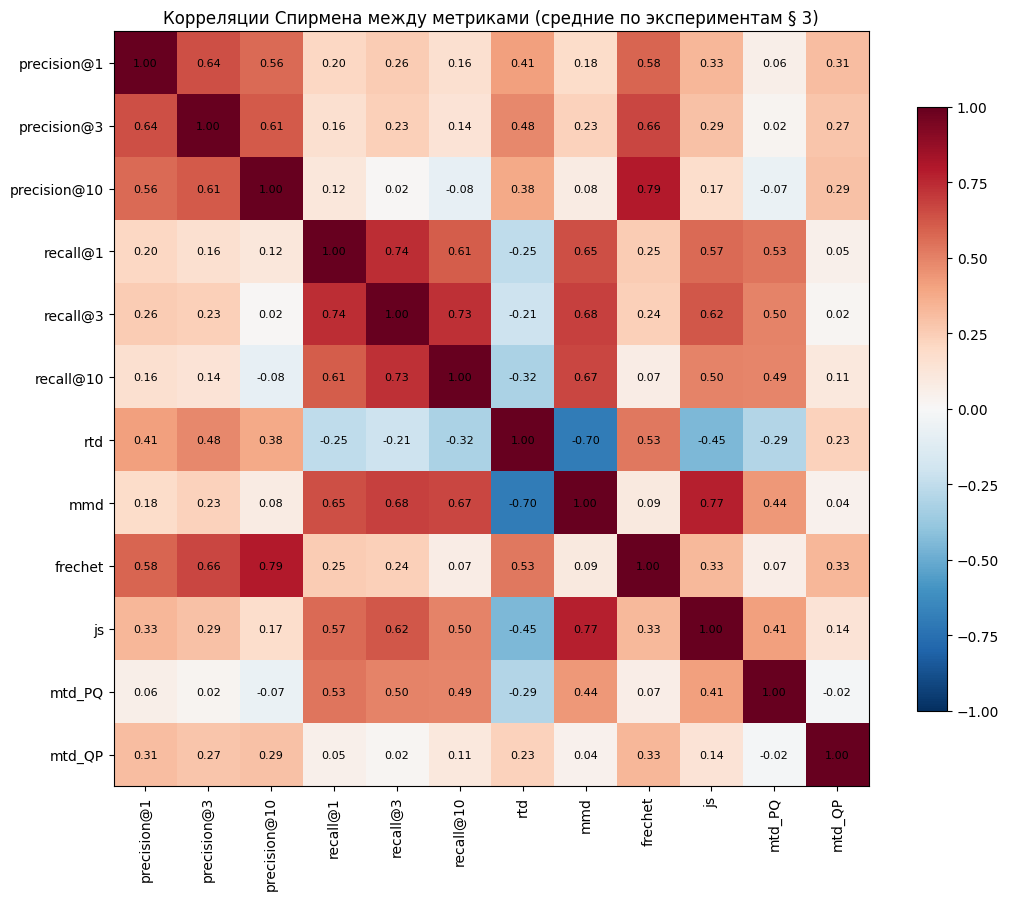

группа B,precision/recall,асимм. топологические,симметричные
группа A,,,
precision/recall,0.340,0.215,0.337
асимм. топологические,0.215,-0.017,0.171
симметричные,0.337,0.171,0.096


,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10,rtd,mmd,frechet,js,mtd_PQ,mtd_QP
precision@1,1.000,0.644,0.563,0.203,0.256,0.159,0.413,0.181,0.581,0.333,0.057,0.310
precision@3,0.644,1.000,0.610,0.161,0.235,0.136,0.482,0.234,0.664,0.293,0.024,0.274
precision@10,0.563,0.610,1.000,0.116,0.016,-0.079,0.376,0.083,0.795,0.174,-0.070,0.289
recall@1,0.203,0.161,0.116,1.000,0.741,0.608,-0.253,0.648,0.250,0.567,0.534,0.049
recall@3,0.256,0.235,0.016,0.741,1.000,0.731,-0.211,0.680,0.242,0.623,0.495,0.020
recall@10,0.159,0.136,-0.079,0.608,0.731,1.000,-0.318,0.666,0.075,0.498,0.491,0.107
rtd,0.413,0.482,0.376,-0.253,-0.211,-0.318,1.000,-0.698,0.529,-0.447,-0.295,0.233
mmd,0.181,0.234,0.083,0.648,0.680,0.666,-0.698,1.000,0.094,0.774,0.437,0.042
frechet,0.581,0.664,0.795,0.250,0.242,0.075,0.529,0.094,1.000,0.327,0.066,0.330
js,0.333,0.293,0.174,0.567,0.623,0.498,-0.447,0.774,0.327,1.000,0.414,0.140


In [ ]:
all_experiments = pd.concat([exp1, exp2a, exp2b, exp3a, exp3b, exp4], ignore_index=True)

corr = trajectories_correlation(all_experiments)
plot_correlation_heatmap(corr, 'Корреляции Спирмена между метриками (средние по экспериментам § 3)')
display(group_correlation_summary(corr).round(3))
corr.round(3)


## 5. Реальные данные: CLIP-эмбеддинги

Синтетика управляемая, но «игрушечная». Здесь тот же набор метрик применяется к распределениям **эмбеддингов реальных данных**: картинки проходят через предобученный CLIP ViT-B/32, облако 512-мерных L2-нормализованных векторов — «выборка из распределения».

Выбор CLIP не случаен: в статье «Rethinking FID» (из литературы научрука) метрика CMMD — MMD на CLIP-эмбеддингах — предложена как замена FID. Связка «CLIP + `compute_all`» покрывает CMMD и добавляет топологию.

Сценарии — прямые аналоги синтетики:

| Реальный сценарий | Синтетический аналог |
|---|---|
| MNIST train vs MNIST test | тот же закон, разные сиды (§ 2.3) |
| MNIST vs Fashion-MNIST | далекие распределения |
| CIFAR-10 → CIFAR-10-C, severity 1→5 | сдвиг кольца (§ 3.1) |
| модель = цифры 0..k, k = 1..9 | раздвигающаяся смесь (§ 3.4) |

> **Оговорки:** в 512 измерениях kNN-оценки (JS, precision/recall) менее надежны, чем в 2D (концентрация расстояний); абсолютные значения метрик между разными пространствами признаков несравнимы. Предмет анализа — поведение метрик относительно друг друга. Время раздела: ~15 минут (из них ~4 — извлечение эмбеддингов).


In [ ]:
!pip install -q ftfy regex
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q imagecorruptions


  Preparing metadata (setup.py) ... done


In [ ]:
import os

import torch
import clip
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model, preprocess = clip.load('ViT-B/32', device=device)
print('CLIP ViT-B/32 на', device)

N_EMB = 1500


def to_rgb(image):
    if isinstance(image, np.ndarray):
        image = Image.fromarray(np.asarray(image, dtype=np.uint8))
    return image.convert('RGB')


@torch.no_grad()
def clip_embeddings(images, batch_size=256, desc='CLIP'):
    """L2-нормализованные CLIP-эмбеддинги, shape (n, 512)."""
    features = []
    for i in tqdm(range(0, len(images), batch_size), desc=desc):
        batch = torch.stack([preprocess(to_rgb(img)) for img in images[i:i + batch_size]])
        features.append(clip_model.encode_image(batch.to(device)).cpu().float().numpy())
    features = np.concatenate(features)
    features /= np.linalg.norm(features, axis=1, keepdims=True)
    return features


def get_embeddings(name, images):
    """Извлекает и кэширует эмбеддинги (npy в ./embeddings)."""
    os.makedirs('embeddings', exist_ok=True)
    path = f'embeddings/{name}.npy'
    if os.path.exists(path):
        return np.load(path)
    features = clip_embeddings(images, desc=name)
    np.save(path, features)
    return features


def subsample(X, n, seed):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=min(n, len(X)), replace=False)
    return X[idx]


CLIP ViT-B/32 на cuda


### 5.1. Датасеты и эмбеддинги

MNIST (train/test), Fashion-MNIST и CIFAR-10 (test) — скачиваются torchvision, эмбеддинги кэшируются в `./embeddings` (повторный запуск ячейки не пересчитывает). Извлечение ~90k картинок ≈ 3–4 минуты на T4.


In [ ]:
from torchvision import datasets as tvd

mnist_train = tvd.MNIST('data', train=True, download=True)
mnist_test = tvd.MNIST('data', train=False, download=True)
fashion_test = tvd.FashionMNIST('data', train=False, download=True)
cifar10_test = tvd.CIFAR10('data', train=False, download=True)

emb_mnist_train = get_embeddings('mnist_train', mnist_train.data.numpy())
emb_mnist_test = get_embeddings('mnist_test', mnist_test.data.numpy())
emb_fashion_test = get_embeddings('fashion_test', fashion_test.data.numpy())
emb_cifar10 = get_embeddings('cifar10_test', cifar10_test.data)

for name, X in [('mnist_train', emb_mnist_train), ('mnist_test', emb_mnist_test),
                ('fashion_test', emb_fashion_test), ('cifar10_test', emb_cifar10)]:
    print(f'{name}: {X.shape}')


mnist_train: (60000, 512)
mnist_test: (10000, 512)
fashion_test: (10000, 512)
cifar10_test: (10000, 512)


### 5.2. Sanity и далекие распределения

MNIST train vs test — «тот же закон, разные выборки» (аналог § 2.3): метрики должны быть малыми. MNIST vs Fashion-MNIST — далекие распределения: метрики большие. Отношение этих двух чисел — грубая «разрешающая способность» каждой метрики на реальных данных.


In [ ]:
rows = {
    'MNIST train vs test (sanity)': metrics.compute_all(
        subsample(emb_mnist_train, N_EMB, seed=SEED_DATA),
        subsample(emb_mnist_test, N_EMB, seed=SEED_MODEL),
    ),
    'MNIST vs Fashion-MNIST': metrics.compute_all(
        subsample(emb_mnist_test, N_EMB, seed=SEED_DATA),
        subsample(emb_fashion_test, N_EMB, seed=SEED_MODEL),
    ),
}
display(pd.DataFrame(rows).round(4))


Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.161291s


Evaluating k-NN precision and recall with 1500 samples...


Evaluated k-NN precision and recall in: 0.223198s


,MNIST train vs test (sanity),MNIST vs Fashion-MNIST
mtd_PQ,5.3542,7.7461
mtd_QP,6.5838,10.8396
rtd,52.7307,52.5057
mmd,0.0167,0.6615
frechet,0.0391,0.4664
js,0.0000,0.7090
precision@1,0.5693,0.0000
precision@3,0.8373,0.0013
precision@10,0.9627,0.0027
recall@1,0.5213,0.2307


### 5.3. CIFAR-10 → CIFAR-10-C: постепенная деградация

Прямой аналог сдвиговых экспериментов: фиксированный набор из 4000 картинок CIFAR-10, к каждому применяется `gaussian_noise` нарастающей силы (severity 1→5 — те же типы порч, что в бенчмарке CIFAR-10-C). Данные — чистые эмбеддинги, модель — испорченные; severity = шаг.


CIFAR-10-C: gaussian_noise, severity 1->5:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating k-NN precision and recall with 1500 samples...


Evaluated k-NN precision and recall in: 0.272781s


Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.160723s


Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.173476s


Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.152538s


Evaluating k-NN precision and recall with 1500 samples...


Evaluated k-NN precision and recall in: 0.283813s


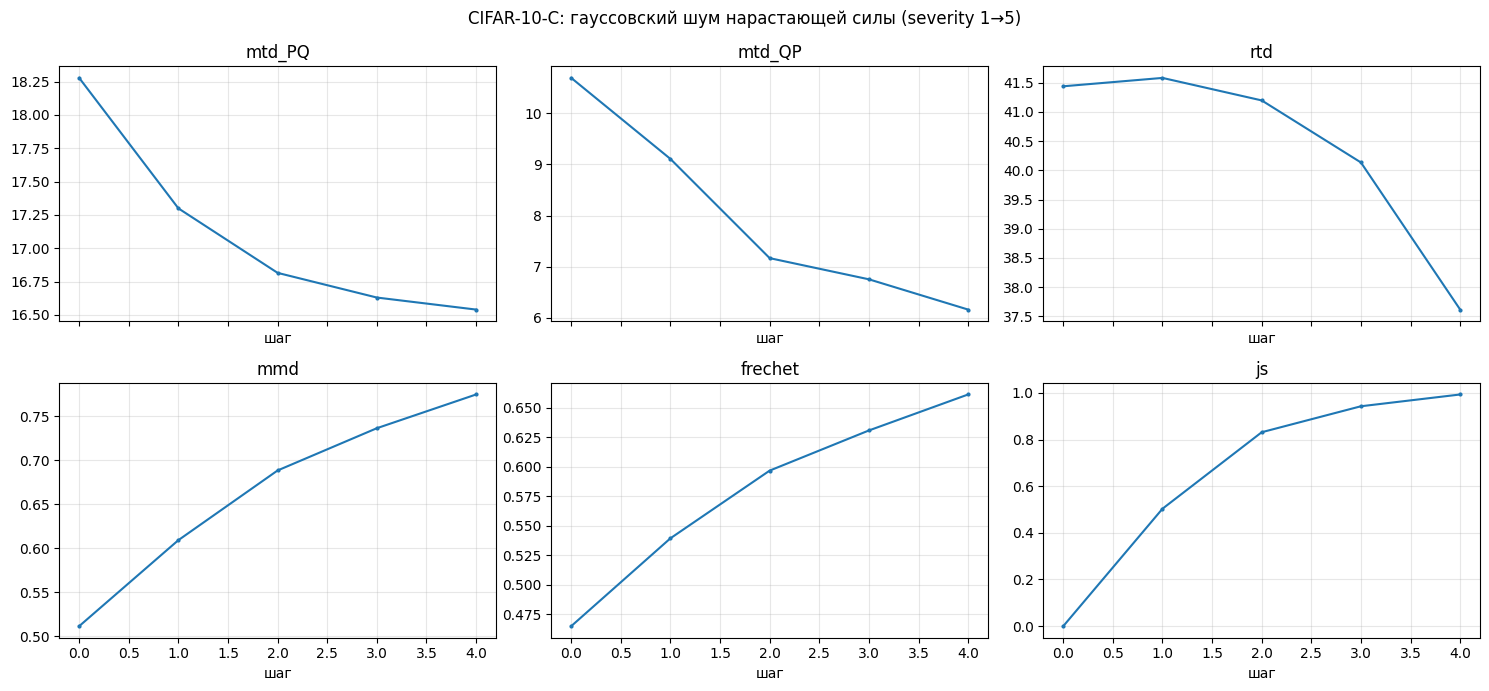

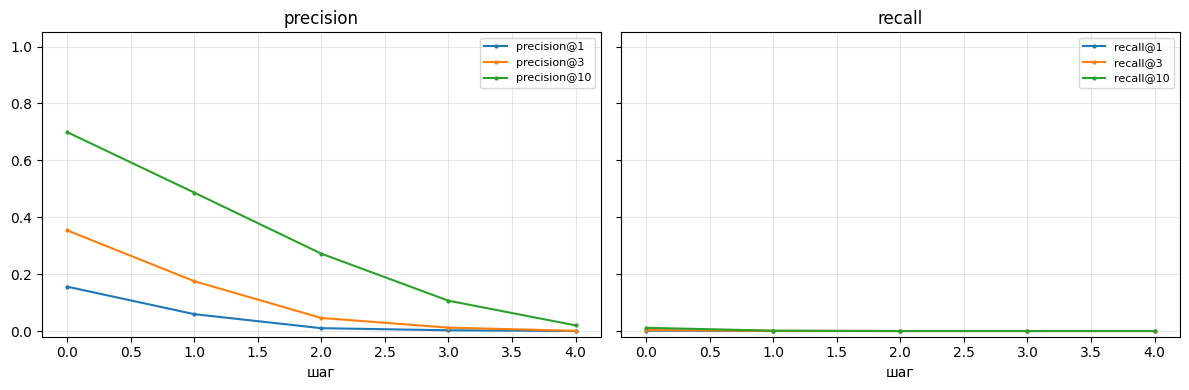

,experiment,step,mtd_PQ,mtd_QP,rtd,mmd,frechet,js,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10
0,"CIFAR-10-C: gaussian_noise, severity 1->5",0,18.2776,10.6866,41.4396,0.5116,0.4647,0.0000,0.1560,0.3540,0.6993,0.0013,0.0033,0.0113
1,"CIFAR-10-C: gaussian_noise, severity 1->5",1,17.2988,9.1044,41.5831,0.6092,0.5392,0.5034,0.0593,0.1753,0.4867,0.0000,0.0007,0.0013
2,"CIFAR-10-C: gaussian_noise, severity 1->5",2,16.8148,7.1678,41.1976,0.6883,0.5966,0.8314,0.0100,0.0460,0.2720,0.0000,0.0000,0.0000
3,"CIFAR-10-C: gaussian_noise, severity 1->5",3,16.6298,6.7544,40.1346,0.7362,0.6307,0.9427,0.0027,0.0120,0.1067,0.0000,0.0000,0.0000
4,"CIFAR-10-C: gaussian_noise, severity 1->5",4,16.5396,6.1636,37.6150,0.7745,0.6612,0.9932,0.0000,0.0007,0.0200,0.0000,0.0000,0.0000


In [ ]:
from imagecorruptions import corrupt

corruption = 'gaussian_noise'
severities = [1, 2, 3, 4, 5]
base_idx = np.random.default_rng(SEED_DATA).choice(len(cifar10_test.data), 4000, replace=False)
base_images = list(cifar10_test.data[base_idx])

clean = get_embeddings('cifar_clean', base_images)
corrupted = {
    severity: get_embeddings(
        f'cifar_{corruption}_s{severity}',
        [corrupt(img, corruption_name=corruption, severity=severity) for img in base_images],
    )
    for severity in severities
}

df_cifar = run_experiment(
    f'CIFAR-10-C: {corruption}, severity 1->5',
    data_fn=lambda step: subsample(clean, N_EMB, seed=SEED_DATA),
    model_fn=lambda step: subsample(corrupted[severities[step]], N_EMB, seed=SEED_MODEL),
    n_steps=len(severities),
)
plot_trajectories(df_cifar, 'CIFAR-10-C: гауссовский шум нарастающей силы (severity 1→5)')
df_cifar.round(4)


### 5.4. MNIST: рост числа классов в модели

Аналог раздвигающейся смеси: модель видит только цифры $0..k$ ($k$ = 1..9), данные — все 10 классов. С ростом $k$ модель приближается к данным — расходимости падают, precision/recall растут. $k = 1$ — одна «компонента», $k = 9$ — почти полное покрытие.


MNIST: рост числа классов в модели:   0%|          | 0/9 [00:00<?, ?it/s]

Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.160915s


Evaluating k-NN precision and recall with 1500 samples...


Evaluated k-NN precision and recall in: 0.27686s


Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.15571s


...

Evaluating k-NN precision and recall with 1500 samples...


Evaluated k-NN precision and recall in: 0.271893s


Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.154107s


Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.159923s


Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.154257s


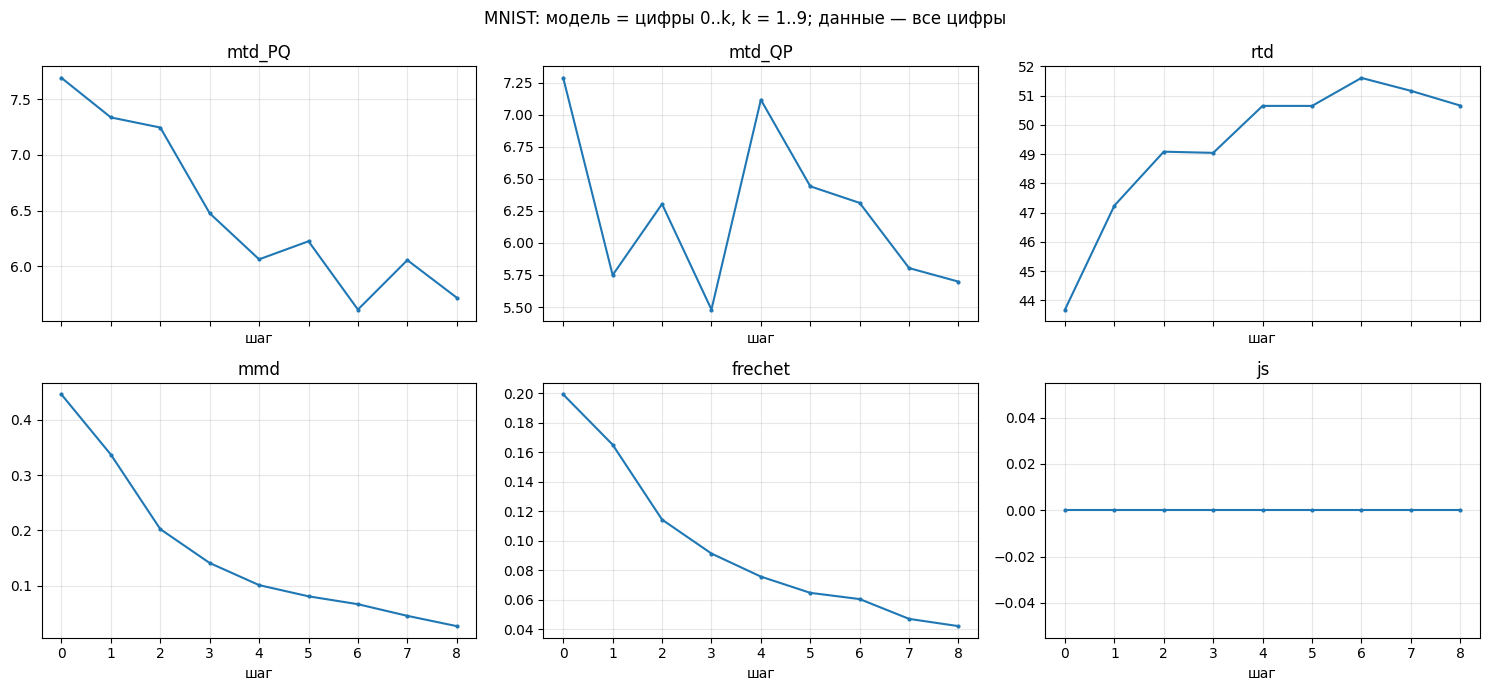

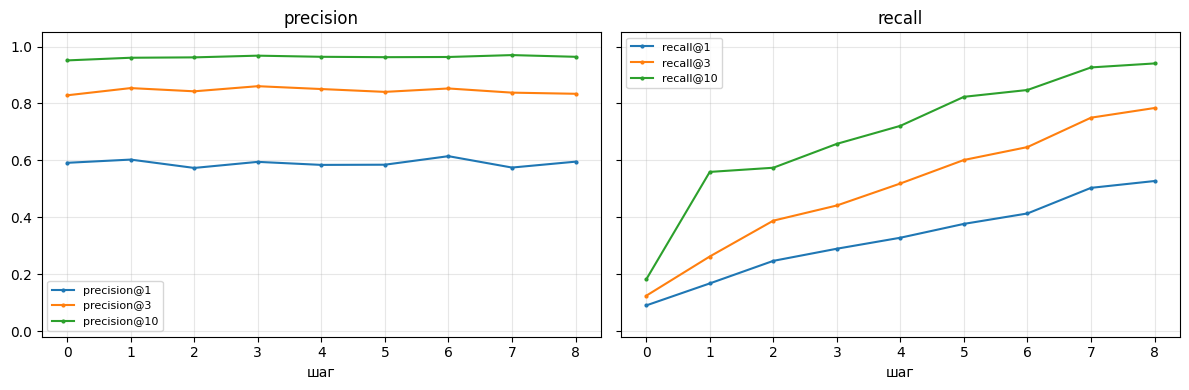

,experiment,step,mtd_PQ,mtd_QP,rtd,mmd,frechet,js,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10
0,MNIST: рост числа классов в модели,0,7.6920,7.2877,43.6880,0.4458,0.1993,0.0,0.5913,0.8287,0.9513,0.0900,0.1240,0.1813
1,MNIST: рост числа классов в модели,1,7.3369,5.7491,47.2440,0.3371,0.1653,0.0,0.6027,0.8540,0.9607,0.1673,0.2620,0.5593
2,MNIST: рост числа классов в модели,2,7.2462,6.3039,49.0871,0.2023,0.1145,0.0,0.5733,0.8427,0.9620,0.2467,0.3880,0.5740
3,MNIST: рост числа классов в модели,3,6.4757,5.4801,49.0466,0.1411,0.0914,0.0,0.5947,0.8607,0.9680,0.2893,0.4413,0.6580
4,MNIST: рост числа классов в модели,4,6.0620,7.1172,50.6527,0.1011,0.0758,0.0,0.5840,0.8507,0.9640,0.3280,0.5187,0.7213
5,MNIST: рост числа классов в модели,5,6.2242,6.4419,50.6518,0.0809,0.0648,0.0,0.5847,0.8407,0.9627,0.3767,0.6013,0.8233
6,MNIST: рост числа классов в модели,6,5.6106,6.3124,51.6091,0.0666,0.0606,0.0,0.6147,0.8527,0.9633,0.4133,0.6467,0.8473
7,MNIST: рост числа классов в модели,7,6.0550,5.8039,51.1684,0.0455,0.0471,0.0,0.5747,0.8380,0.9700,0.5033,0.7500,0.9267
8,MNIST: рост числа классов в модели,8,5.7176,5.6981,50.6641,0.0269,0.0422,0.0,0.5953,0.8340,0.9640,0.5273,0.7840,0.9407


In [ ]:
targets = mnist_train.targets.numpy()


def class_embeddings(c, n_per_class, seed):
    idx = np.where(targets == c)[0]
    selected = np.random.default_rng(seed).choice(idx, size=n_per_class, replace=False)
    return emb_mnist_train[selected]


per_class = {c: class_embeddings(c, n_per_class=N_EMB, seed=SEED_DATA + c) for c in range(10)}

df_mnist_classes = run_experiment(
    'MNIST: рост числа классов в модели',
    data_fn=lambda step: subsample(emb_mnist_train, N_EMB, seed=SEED_DATA),
    model_fn=lambda step: subsample(
        np.concatenate([per_class[c] for c in range(step + 1)]),
        N_EMB,
        seed=SEED_MODEL,
    ),
    n_steps=9,
)
plot_trajectories(df_mnist_classes, 'MNIST: модель = цифры 0..k, k = 1..9; данные — все цифры')
df_mnist_classes.round(4)


### 5.5. Корреляции метрик на реальных данных

Тот же анализ, что в § 4, но на траекториях § 5 (CIFAR-10-C + рост классов). Сравниваем с синтетикой: держится ли группировка «precision/recall ↔ симметричные ↔ асимметричные топологические» на реальных распределениях.


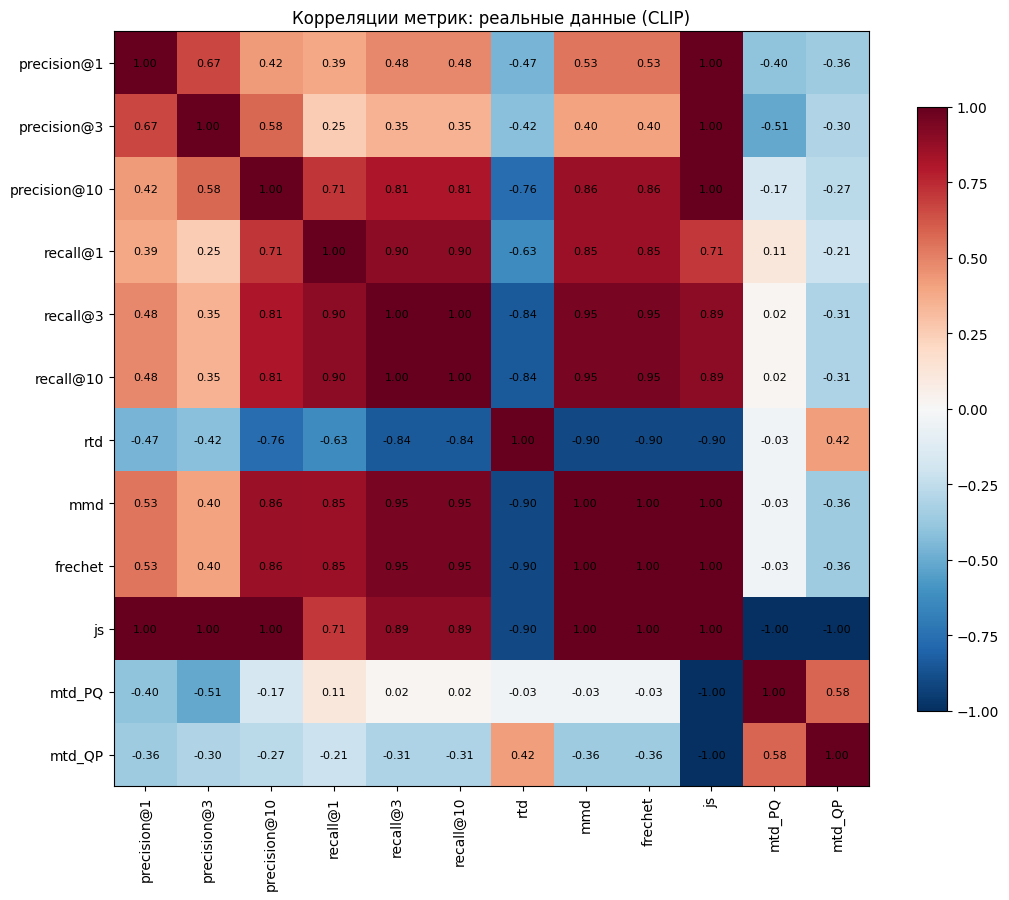

группа B,precision/recall,асимм. топологические,симметричные
группа A,,,
precision/recall,0.605,-0.222,0.443
асимм. топологические,-0.222,0.583,-0.300
симметричные,0.443,-0.300,0.050


,precision@1,precision@3,precision@10,recall@1,recall@3,recall@10,rtd,mmd,frechet,js,mtd_PQ,mtd_QP
precision@1,1.000,0.667,0.425,0.387,0.481,0.481,-0.467,0.533,0.533,1.000,-0.400,-0.358
precision@3,0.667,1.000,0.575,0.254,0.347,0.347,-0.417,0.400,0.400,1.000,-0.508,-0.300
precision@10,0.425,0.575,1.000,0.713,0.807,0.807,-0.764,0.860,0.860,1.000,-0.165,-0.266
recall@1,0.387,0.254,0.713,1.000,0.895,0.895,-0.627,0.854,0.854,0.707,0.113,-0.212
recall@3,0.481,0.347,0.807,0.895,1.000,1.000,-0.841,0.947,0.947,0.894,0.019,-0.306
recall@10,0.481,0.347,0.807,0.895,1.000,1.000,-0.841,0.947,0.947,0.894,0.019,-0.306
rtd,-0.467,-0.417,-0.764,-0.627,-0.841,-0.841,1.000,-0.900,-0.900,-0.900,-0.033,0.417
mmd,0.533,0.400,0.860,0.854,0.947,0.947,-0.900,1.000,1.000,1.000,-0.033,-0.358
frechet,0.533,0.400,0.860,0.854,0.947,0.947,-0.900,1.000,1.000,1.000,-0.033,-0.358
js,1.000,1.000,1.000,0.707,0.894,0.894,-0.900,1.000,1.000,1.000,-1.000,-1.000


In [ ]:
df_real = pd.concat([df_cifar, df_mnist_classes], ignore_index=True)

corr_real = trajectories_correlation(df_real)
plot_correlation_heatmap(corr_real, 'Корреляции метрик: реальные данные (CLIP)')
display(group_correlation_summary(corr_real).round(3))
corr_real.round(3)


### 5.6. (Опционально) Сырые пиксели vs CLIP

Тот же вопрос «MNIST vs Fashion-MNIST», но «эмбеддинги» — сами пиксели (784-dim). Абсолютные значения между строками **несравнимы** (разные пространства и масштабы) — смотрим на паттерн: насколько каждая метрика видит разницу распределений в исходном пространстве vs пространстве предобученной модели. Это проверка чувствительности выводов к выбору признакового пространства.


In [ ]:
pixels_mnist = mnist_train.data.numpy().reshape(len(mnist_train), -1).astype(np.float32) / 255.0
pixels_fashion = fashion_test.data.numpy().reshape(len(fashion_test), -1).astype(np.float32) / 255.0

rows = {
    'CLIP: MNIST vs Fashion': metrics.compute_all(
        subsample(emb_mnist_test, N_EMB, seed=SEED_DATA),
        subsample(emb_fashion_test, N_EMB, seed=SEED_MODEL),
    ),
    'пиксели: MNIST vs Fashion': metrics.compute_all(
        subsample(pixels_mnist, N_EMB, seed=SEED_DATA),
        subsample(pixels_fashion, N_EMB, seed=SEED_MODEL),
    ),
}
display(pd.DataFrame(rows).round(4))


Evaluating k-NN precision and recall with 1500 samples...
Evaluated k-NN precision and recall in: 0.157619s


Evaluating k-NN precision and recall with 1500 samples...


Evaluated k-NN precision and recall in: 0.256709s


,CLIP: MNIST vs Fashion,пиксели: MNIST vs Fashion
mtd_PQ,7.7461,442.7317
mtd_QP,10.8396,173.4037
rtd,52.5057,63.7770
mmd,0.6615,0.3797
frechet,0.4664,8.8365
js,0.7090,0.0000
precision@1,0.0000,0.0893
precision@3,0.0013,0.1240
precision@10,0.0027,0.2320
recall@1,0.2307,0.0007


## 6. Итоги

**Инженерное:** единый пайплайн «данные → `TopologyMetrics.compute_all` → `DataFrame` → графики/корреляции»; все задачи из переписки закрыты (таблица в начале ноутбука); библиотечные грабли задокументированы в § 2.2 (батчи MTD, симметричность RTD, nhood_sizes, TF1-режим).

**Что показали эксперименты (свойства метрик, а не только цифры):**

1. **Корректность**: на точной копии все метрики дают ровно 0/1 (§ 2.3); ненулевые значения на «одинаковых с виду» облаках — шум сэмплирования двух независимых выборок, он же калибрует нулевой шаг каждого эксперимента.
2. **RTD инвариантен к сдвигам** (§ 3.1–3.3): траектория — константа, потому что матрица RTD строится только из внутренних попарных расстояний облаков. Сдвиговые эксперименты его не измеряют — измеряют внутренние деформации (§ 3.4–3.6).
3. **Fréchet distance (и классический FID) слеп к раздвиганию смеси с сохранением моментов** (§ 3.4–3.5): ≈ 0.1 на всех 15 шагах, пока JS растет до 0.75, MMD и топологические метрики реагируют. Метрики «по моментам» не видят мультимодальность такого типа.
4. **Precision/recall-картина mode dropping** (§ 3.4–3.5): при разделении смеси precision@3 и recall@3 расходятся зеркально (0.98/0.18 в одном направлении, 0.18/0.99 в другом) — ровно та семантика, ради которой PR-метрики и существуют.
5. **Асимметрия MTD** (§ 3.4–3.5): направления $P \to Q$ и $Q \to P$ отвечают на одну деформацию по-разному (7.8→11.4 и 7.6→4.4 на тех же данных).
6. **Корреляционный анализ** (§ 4): гипотеза научрука «PR-метрики похожи между собой сильнее, чем с симметричными» в чистом виде **не подтвердилась**: внутри-PR 0.34 против PR↔симметричные 0.34. Реальная структура интереснее — метрики группируются по *измеряемому аспекту*, а не по семейству: `recall@k` + `mmd` + `js` образуют кластер «покрытия» (0.6–0.8); в экспериментах со смесью precision и recall расходятся в противоположные стороны (mode dropping: 0.98/0.18), и так же расходятся направления MTD (в итоге `mtd_PQ`↔`mtd_QP` ≈ 0); `rtd` антикоррелирует с `mmd`/`js` (−0.7): при раздвигании смеси расходимость растет, а внутренняя структура облаков упрощается — rtd падает. На реальных данных (§ 5) картина похожая: монотонные траектории дают идеальную корреляцию mmd/frechet/js, rtd снова «сам по себе» (−0.9), направления MTD совпадают (0.58). Оговорка: в § 5 всего два эксперимента, корреляции там грубые.
7. **Реальные данные** (§ 5): тот же аппарат на CLIP-эмбеддингах (подход CMMD из «Rethinking FID»). Паттерны повторяются: рост классов в модели поднимает recall (0.12 → 0.94) при стабильном precision (~0.83) — подмножество классов это «модель без фальшивых мод, но с неполным покрытием»; CIFAR-10-C дает монотонную деградацию по mmd/Fréchet/precision. Важная оговорка: **MTD/RTD на 512-мерных CLIP-эмбеддингах при N=1500 дискриминируют слабо** (mtd меняется на десятки процентов, тогда как mmd — на порядок) — концентрация расстояний в высоких размерностях ослабляет топологические сигналы; для топологических метрик на эмбеддингах нужны б'ольшие выборки, и выводы по ним на реальных данных надо делать осторожно.

**Что дальше (естественные продолжения):**

- обучить простую генеративную модель (VAE/диффузия на MNIST) и сравнивать реал/генерации по чекпоинтам — «динамика обучения» глазами всех метрик;
- другие типы порч CIFAR-10-C (`pixelate`, `gaussian_blur`, ...);
- другие бэкбоны (ResNet-50, DINOv2) — устойчивость корреляционной картины к выбору признакового пространства;
- формальные статистические тесты для корреляций (перестановочные), доверительные интервалы метрик через бутстрап облаков.


## Литература

**Метрики:**

- Barannikov S., Trofimov I., Sotnikov G., et al. *Manifold Topology Divergence: a Framework for Comparing Data Manifolds.* NeurIPS 2021. [arXiv:2106.04024](https://arxiv.org/abs/2106.04024) — MTD; библиотека [MTopDiv](https://github.com/IlyaTrofimov/MTopDiv).
- Barannikov S., Trofimov I., Balabin N., Burnaev E. *Representation Topology Divergence: A Method for Comparing Neural Network Representations.* ICML 2022. [arXiv:2201.00058](https://arxiv.org/abs/2201.00058) — RTD; библиотека [RTD](https://github.com/IlyaTrofimov/RTD).
- Kynkäänniemi T., Karras T., Laine S., Lehtinen J., Aila T. *Improved Precision and Recall for Assessing Generative Models.* NeurIPS 2019. [arXiv:1904.06991](https://arxiv.org/abs/1904.06991) — improved precision/recall; [форк для Colab](https://github.com/AlimAlb/improved-precision-and-recall-metric).
- Heusel M., Ramsauer H., Unterthiner T., Nessler B., Hochreiter S. *GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium.* NeurIPS 2017. [arXiv:1706.08500](https://arxiv.org/abs/1706.08500) — Fréchet Inception Distance.
- Gretton A., Borgwardt K., Rasch M., Schölkopf B., Smola A. *A Kernel Two-Sample Test.* JMLR 2012 — MMD.
- Kozachenko L., Leonenko N. *Sample Estimate of the Entropy of a Random Vector.* Probl. Inf. Transm. 1987 — kNN-оценка энтропии (используется в JS).
- Lin J. *Divergence measures based on the Shannon entropy.* IEEE Trans. Inf. Theory 1991 — дивергенция Дженсена–Шеннона.

**Из списка научного руководителя:**

- Jayasumana S. et al. *Rethinking FID: Towards a Better Evaluation Metric for Image Generation.* 2024. [arXiv:2401.09603](https://arxiv.org/abs/2401.09603) — CMMD (CLIP + MMD), критика FID.
- *Manifoldron: Direct Space Partition via Manifold Discovery.* 2022. [arXiv:2201.05279](https://arxiv.org/abs/2201.05279).
- *Topological Alternatives for Precision and Recall in Generative Models.* IEEE 2025. [ieeexplore.ieee.org/document/11123796](https://ieeexplore.ieee.org/abstract/document/11123796).

**Инструменты:**

- Zhang S. et al. *Ripser++: A GPU-based tool for computing persistence barcodes.* [github.com/simonzhang00/ripser-plusplus](https://github.com/simonzhang00/ripser-plusplus) — персистентные гомологии на GPU.
- Radford A. et al. *Learning Transferable Visual Models From Natural Language Supervision.* ICML 2021 — CLIP.
- Hendrycks D., Dietterich T. *Benchmarking Neural Network Robustness to Common Corruptions and Perturbations.* ICLR 2019 — CIFAR-10-C, пакет `imagecorruptions`.
